In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.multioutput import MultiOutputRegressor
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# =========================================
# 1. Configuration & Reproducibility
# =========================================
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seeds set to {seed}.")

set_seeds(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =========================================
# 2. Data Loading & Preprocessing
# =========================================
file_path = '../Data/FINAL_4CLASSES.csv' 

if not os.path.exists(file_path):
    print(f"Error: {file_path} not found. Please ensure the dataset is uploaded.")
else:
    df = pd.read_csv(file_path, encoding='utf-8', engine='python')

    # Column Mapping
    column_mapping = {
        'Gain(db)': 'Gain(dB)', 'Gain': 'Gain(dB)', 'gain': 'Gain(dB)', 
        'Bandwidth': 'Bandwidth(Hz)', 'bandwidth': 'Bandwidth(Hz)', 
        'GBW': 'GBW(MHz)', 'gbw': 'GBW(MHz)', 
        'Power': 'Power(uW)', 'power': 'Power(uW)', 
        'PM': 'PM(degree)', 'PhaseMargin': 'PM(degree)',
        'GM': 'GM(dB)',
        'PSRR': 'PSRR(dB)',
        'SlewRate': 'SlewRate (V/us)', 'SlewRate(V/µs)': 'SlewRate (V/us)',
        'CMRR': 'CMRR(dB)', 'class': 'Class', 'CLASS': 'Class'
    }
    df.rename(columns={k: v for k, v in column_mapping.items() if k in df.columns}, inplace=True)

    # Constants & Fixed Units
    df['Idc(uA)'] = 130.0
    df['Length(um)'] = 0.18
    df['CL(pF)'] = 10.0 
    df['CC(pF)'] = 55.0

    # Feature Selection
    FEATURE_COLUMNS = [
        'Temperature(°)', 'W12(um)', 'W34(um)', 'W58(um)', 'W6(um)', 'W7(um)', 
        'Idc(uA)', 'Length(um)', 'CC(pF)', 'CL(pF)'
    ]

    REGRESSION_TARGETS = [
        'Gain(dB)', 'Bandwidth(Hz)', 'GBW(MHz)', 'Power(uW)', 'PM(degree)', 
        'GM(dB)', 'PSRR(dB)', 'SlewRate (V/us)', 'CMRR(dB)'
    ]
    CLASSIFICATION_TARGET = 'Class'

    # Handle Missing Values
    X_raw = df[FEATURE_COLUMNS].fillna(df[FEATURE_COLUMNS].mean())
    y_reg_raw = df[REGRESSION_TARGETS].fillna(df[REGRESSION_TARGETS].mean())
    y_class_raw = df[CLASSIFICATION_TARGET].fillna(df[CLASSIFICATION_TARGET].mode()[0])

    # Scaling
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X_raw)

    scaler_y_reg = StandardScaler()
    y_reg_scaled = scaler_y_reg.fit_transform(y_reg_raw)

    le = LabelEncoder()
    y_class_labels = le.fit_transform(y_class_raw)
    n_classes = len(le.classes_)

    print("Data Loaded and Preprocessed Successfully.")

# =========================================
# 3. Model Definitions
# =========================================

class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_reg_outputs, n_classes, dropout_rate):
        super(PINN, self).__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate)) 
            prev_dim = hidden_dim
        
        self.backbone = nn.Sequential(*layers)
        self.regression_head = nn.Linear(prev_dim, n_reg_outputs)
        self.classification_head = nn.Linear(prev_dim, n_classes)

    def forward(self, x):
        shared_output = self.backbone(x)
        reg_output = self.regression_head(shared_output)
        class_output = self.classification_head(shared_output)
        return reg_output, class_output

class StandardMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_reg_outputs, n_classes, dropout_rate):
        super(StandardMLP, self).__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        self.backbone = nn.Sequential(*layers)
        self.regression_head = nn.Linear(prev_dim, n_reg_outputs)
        self.classification_head = nn.Linear(prev_dim, n_classes)

    def forward(self, x):
        shared = self.backbone(x)
        return self.regression_head(shared), self.classification_head(shared)

# =========================================
# 4. Helper Functions (Loss, Physics, Complexity)
# =========================================
def get_model_complexity(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def physics_loss_normalized(x_tensor_scaled, y_pred_reg_scaled, scaler_X, scaler_y_reg, feature_names, regression_target_names):
    device = x_tensor_scaled.device
    x_mean = torch.tensor(scaler_X.mean_, dtype=torch.float32, device=device)
    x_scale = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
    y_mean = torch.tensor(scaler_y_reg.mean_, dtype=torch.float32, device=device)
    y_scale = torch.tensor(scaler_y_reg.scale_, dtype=torch.float32, device=device)

    x_unscaled_tensor = x_tensor_scaled * x_scale + x_mean
    y_pred_unscaled_tensor = y_pred_reg_scaled * y_scale + y_mean

    feature_map = {name: x_unscaled_tensor[:, i] for i, name in enumerate(feature_names)}
    W12, W34, W6 = feature_map['W12(um)'], feature_map['W34(um)'], feature_map['W6(um)']
    Idc, L, Cc = feature_map['Idc(uA)'], feature_map['Length(um)'], feature_map['CC(pF)']
    
    gain_pred = y_pred_unscaled_tensor[:, regression_target_names.index('Gain(dB)')]
    bw_pred = y_pred_unscaled_tensor[:, regression_target_names.index('Bandwidth(Hz)')]
    gbw_pred = y_pred_unscaled_tensor[:, regression_target_names.index('GBW(MHz)')]
    pm_pred = y_pred_unscaled_tensor[:, regression_target_names.index('PM(degree)')]
    sr_pred = y_pred_unscaled_tensor[:, regression_target_names.index('SlewRate (V/us)')]
    power_pred = y_pred_unscaled_tensor[:, regression_target_names.index('Power(uW)')]
    cmrr_pred = y_pred_unscaled_tensor[:, regression_target_names.index('CMRR(dB)')]

    u_nCox, u_pCox = 343.98, 107.1
    lambda_n, lambda_p = 0.1, 0.2
    VDD, pi = 1.8, 3.14159
    Id1_amps, Cc_farads = (Idc / 2) * 1e-6, Cc * 1e-12
    
    gm12 = torch.sqrt(2 * u_nCox * (W12 / L) * (Idc / 2)) * 1e-6
    gm34 = torch.sqrt(2 * u_pCox * (W34 / L) * (Idc / 2)) * 1e-6
    gm6  = torch.sqrt(2 * u_nCox * (W6 / L) * Idc) * 1e-6
    gm_avg = (gm12 + gm34 + gm6) / 3
    ro12 = (1 / (lambda_n * (Idc / 2))) * 1e6
    ro34 = (1 / (lambda_p * (Idc / 2))) * 1e6
    ro6  = (1 / (lambda_n * Idc)) * 1e6
    ro7  = (1 / (lambda_n * Idc)) * 1e6

    # --- FULL PHYSICS CALCULATIONS ---
    Gain_calc_db = 20 * torch.log10(((gm12 * (ro12 * ro34) / (ro12 + ro34)) * (gm6 * (ro6 * ro7) / (ro6 + ro7)) * 0.033) + 1e-8)
    
    # --- UPDATED GBW PHYSICS FORMULA (Aligned with Block 3) ---
    C1, C2, C3 = 11.28, 0.133, 1e-6
    gain_linear = 10 ** (gain_pred / 20.0)
    pm_correction = (C1 - (C2 * pm_pred))
    GBW_calc_mhz = gain_linear * bw_pred * pm_correction * C3

    SR_calc_vus = ((Id1_amps / Cc_farads) / 1e6) * 2.88
    Power_calc_uw = (VDD * Idc) * 9.17
    CMRR_calc_db = 20 * torch.log10(((gm_avg / 1e-6) * 2.85) + 1e-8)

    # Loss terms
    loss_gain = F.mse_loss(gain_pred, Gain_calc_db) / 6400.0
    loss_gbw = F.mse_loss(gbw_pred, GBW_calc_mhz) / 10000.0
    loss_sr = F.mse_loss(sr_pred, SR_calc_vus) / 400.0
    loss_power = F.mse_loss(power_pred, Power_calc_uw) / 9000000.0
    loss_cmrr = F.mse_loss(cmrr_pred, CMRR_calc_db) / 10000.0

    return loss_gain + loss_gbw + loss_sr + loss_power + loss_cmrr

# =========================================
# 5. Training Loop with History Tracking
# =========================================
def train_dl_model(model, train_loader, val_loader, model_name, epochs=60, is_pinn=False):
    optimizer = optim.Adam(model.parameters(), lr=0.0008657)
    crit_reg = nn.MSELoss()
    crit_class = nn.CrossEntropyLoss()
    
    alpha_max = 0.58 if is_pinn else 0.0
    class_w = 4.30
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    print(f"Training {model_name}...")
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, correct_train, total_train = 0, 0, 0
        alpha = min(alpha_max, alpha_max * (epoch / 50)) if epoch < 50 else alpha_max
        
        for xb, yrb, ycb in train_loader:
            if is_pinn: xb.requires_grad_(True)
            optimizer.zero_grad()
            pr, pc = model(xb)
            
            loss_sup = crit_reg(pr, yrb) + (class_w * crit_class(pc, ycb))
            loss_phys = 0
            if is_pinn:
                loss_phys = physics_loss_normalized(xb, pr, scaler_X, scaler_y_reg, FEATURE_COLUMNS, REGRESSION_TARGETS)
            
            loss = (1 - alpha) * loss_sup + alpha * loss_phys if is_pinn else loss_sup
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(pc.data, 1)
            total_train += ycb.size(0)
            correct_train += (predicted == ycb).sum().item()
            
        # Validation step
        model.eval()
        val_loss, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for xb, yrb, ycb in val_loader:
                pr, pc = model(xb)
                loss_v = crit_reg(pr, yrb) + (class_w * crit_class(pc, ycb))
                val_loss += loss_v.item()
                _, predicted = torch.max(pc.data, 1)
                total_val += ycb.size(0)
                correct_val += (predicted == ycb).sum().item()
        
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_acc'].append(correct_train / total_train)
        history['val_acc'].append(correct_val / total_val)
            
    return model, history

# =========================================
# 6. K-Fold Cross Validation
# =========================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results_reg = []
results_class = []
all_fold_predictions = [] 
training_histories = [] 

total_pinn_training_time = 0
pinn_complexity = 0

print("\nStarting K-Fold Cross Validation...")

fold = 1
for train_idx, test_idx in kf.split(X_scaled, y_reg_scaled):
    print(f"\n=== FOLD {fold} ===")
    
    X_train_fold, X_test_fold = X_scaled[train_idx], X_scaled[test_idx]
    y_reg_train_fold, y_reg_test_fold = y_reg_scaled[train_idx], y_reg_scaled[test_idx]
    y_class_train_fold, y_class_test_fold = y_class_labels[train_idx], y_class_labels[test_idx]
    
    X_train_t = torch.tensor(X_train_fold, dtype=torch.float32).to(device)
    y_reg_train_t = torch.tensor(y_reg_train_fold, dtype=torch.float32).to(device)
    y_class_train_t = torch.tensor(y_class_train_fold, dtype=torch.long).to(device)
    
    X_test_t = torch.tensor(X_test_fold, dtype=torch.float32).to(device)
    y_reg_test_t = torch.tensor(y_reg_test_fold, dtype=torch.float32).to(device)
    y_class_test_t = torch.tensor(y_class_test_fold, dtype=torch.long).to(device)
    
    dl_train = DataLoader(TensorDataset(X_train_t, y_reg_train_t, y_class_train_t), batch_size=64, shuffle=True)
    dl_test = DataLoader(TensorDataset(X_test_t, y_reg_test_t, y_class_test_t), batch_size=64)

    # 1. PINN
    pinn = PINN(X_train_fold.shape[1], [128, 128, 128, 128], len(REGRESSION_TARGETS), n_classes, 0.047).to(device)
    
    if fold == 1:
        pinn_complexity = get_model_complexity(pinn)
    
    start_time = time.time()
    pinn, pinn_hist = train_dl_model(pinn, dl_train, dl_test, "PINN", epochs=50, is_pinn=True)
    total_pinn_training_time += (time.time() - start_time)
    
    pinn.eval()
    with torch.no_grad():
        pr, pc = pinn(X_test_t)
        pred_reg_pinn = scaler_y_reg.inverse_transform(pr.cpu().numpy())
        pred_class_pinn = torch.argmax(pc, dim=1).cpu().numpy()

    # 2. Standard MLP
    mlp = StandardMLP(X_train_fold.shape[1], [128, 128, 128, 128], len(REGRESSION_TARGETS), n_classes, 0.047).to(device)
    mlp, mlp_hist = train_dl_model(mlp, dl_train, dl_test, "Standard MLP", epochs=50, is_pinn=False)
    mlp.eval()
    with torch.no_grad():
        pr, pc = mlp(X_test_t)
        pred_reg_mlp = scaler_y_reg.inverse_transform(pr.cpu().numpy())
        pred_class_mlp = torch.argmax(pc, dim=1).cpu().numpy()

    training_histories.append({'fold': fold, 'PINN': pinn_hist, 'Standard MLP': mlp_hist})

    # 3. Random Forest
    print("Training Random Forest...")
    rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    y_reg_train_raw = scaler_y_reg.inverse_transform(y_reg_train_fold)
    rf_reg.fit(X_train_fold, y_reg_train_raw) 
    pred_reg_rf = rf_reg.predict(X_test_fold)
    rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_clf.fit(X_train_fold, y_class_train_fold)
    pred_class_rf = rf_clf.predict(X_test_fold)

    # 4. SVM
    print("Training SVM...")
    svm_reg = MultiOutputRegressor(SVR(kernel='rbf'))
    svm_reg.fit(X_train_fold, y_reg_train_fold)
    pred_reg_svm = scaler_y_reg.inverse_transform(svm_reg.predict(X_test_fold))
    svm_clf = SVC(kernel='rbf')
    svm_clf.fit(X_train_fold, y_class_train_fold)
    pred_class_svm = svm_clf.predict(X_test_fold)

    # Calculate Metrics
    y_true_reg = scaler_y_reg.inverse_transform(y_reg_test_fold)
    y_true_class = y_class_test_fold
    
    fold_preds = {
        'PINN': (pred_reg_pinn, pred_class_pinn),
        'Standard MLP': (pred_reg_mlp, pred_class_mlp),
        'Random Forest': (pred_reg_rf, pred_class_rf),
        'SVM': (pred_reg_svm, pred_class_svm),
        'y_true_reg': y_true_reg,
        'y_true_class': y_true_class
    }
    all_fold_predictions.append(fold_preds)
    
    for name in ['PINN', 'Standard MLP', 'Random Forest', 'SVM']:
        pr, pc = fold_preds[name]
        results_reg.append({
            'Model': name, 'Fold': fold, 
            'R2': r2_score(y_true_reg, pr), 
            'RMSE': np.sqrt(mean_squared_error(y_true_reg, pr)), 
            'MAE': mean_absolute_error(y_true_reg, pr), 
            'MAPE': mean_absolute_percentage_error(y_true_reg, pr)
        })
        results_class.append({
            'Model': name, 'Fold': fold,
            'Accuracy': accuracy_score(y_true_class, pc), 
            'Precision': precision_score(y_true_class, pc, average='weighted'), 
            'Recall': recall_score(y_true_class, pc, average='weighted'), 
            'F1': f1_score(y_true_class, pc, average='weighted')
        })
    fold += 1

# Final Scores
df_res_reg = pd.DataFrame(results_reg)
df_res_class = pd.DataFrame(results_class)

print("\n" + "="*50)
print("PINN MODEL METRICS")
print("="*50)
print(f"Total Trainable Parameters (Complexity): {pinn_complexity:,}")
print(f"Total K-Fold Training Time: {total_pinn_training_time:.2f} seconds")
print(f"Average Training Time per Fold: {total_pinn_training_time/5:.2f} seconds")

print("\n" + "="*50)
print("FINAL AVERAGE SCORES (Across 5 Folds)")
print("="*50)
print(df_res_reg.groupby('Model')[['R2', 'RMSE', 'MAE', 'MAPE']].mean())
print("\n")
print(df_res_class.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].mean())


Random seeds set to 42.
Using device: cpu
Data Loaded and Preprocessed Successfully.

Starting K-Fold Cross Validation...

=== FOLD 1 ===
Training PINN...
Training Standard MLP...
Training Random Forest...
Training SVM...

=== FOLD 2 ===
Training PINN...
Training Standard MLP...
Training Random Forest...
Training SVM...

=== FOLD 3 ===
Training PINN...
Training Standard MLP...
Training Random Forest...
Training SVM...

=== FOLD 4 ===
Training PINN...
Training Standard MLP...
Training Random Forest...
Training SVM...

=== FOLD 5 ===
Training PINN...
Training Standard MLP...
Training Random Forest...
Training SVM...

PINN MODEL METRICS
Total Trainable Parameters (Complexity): 52,750
Total K-Fold Training Time: 700.09 seconds
Average Training Time per Fold: 140.02 seconds

FINAL AVERAGE SCORES (Across 5 Folds)
                     R2         RMSE         MAE      MAPE
Model                                                     
PINN           0.989824  1306.617333  253.176209  0.021507
Rand

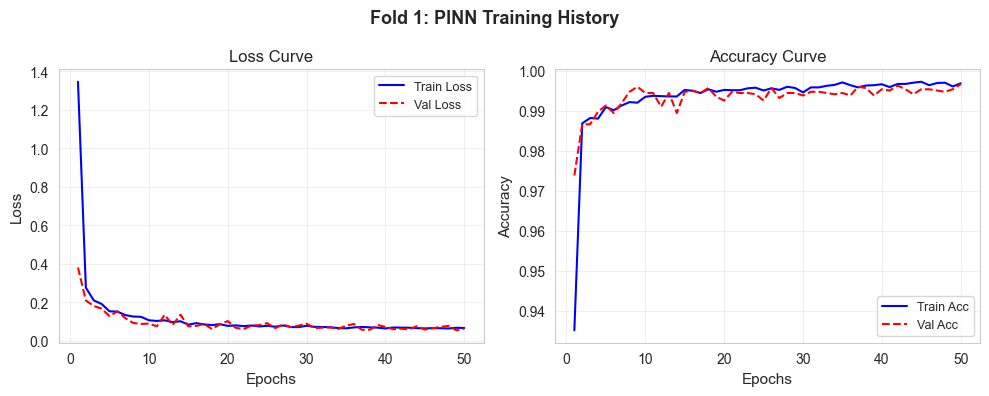

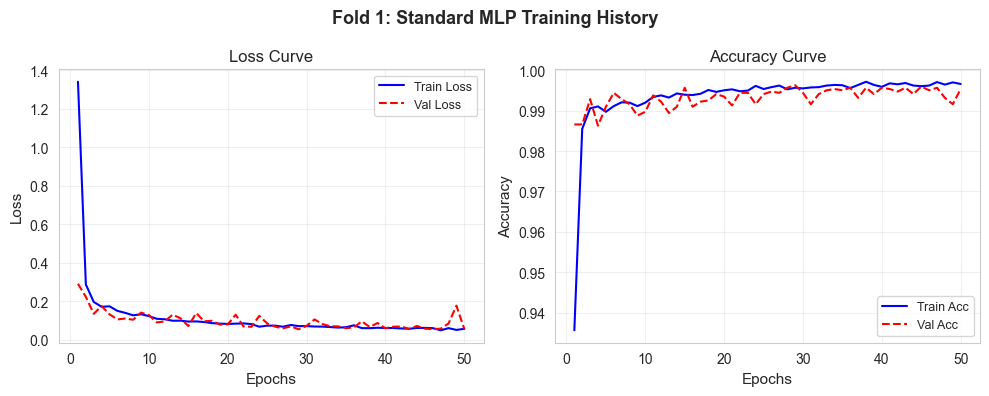

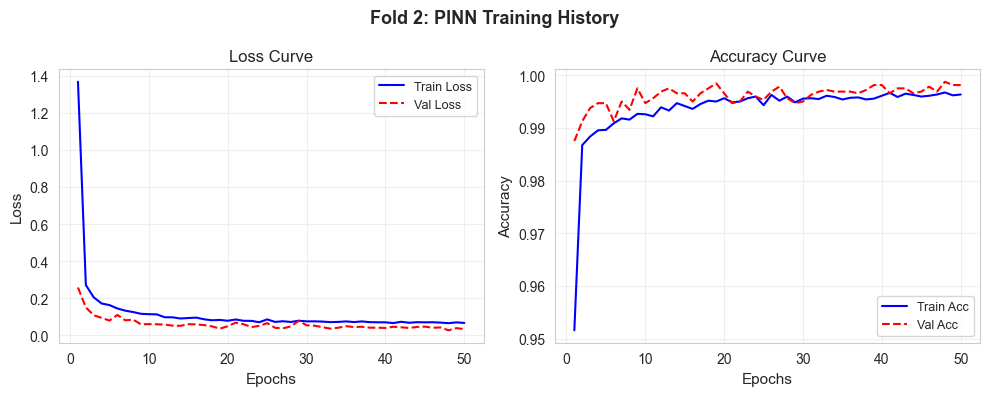

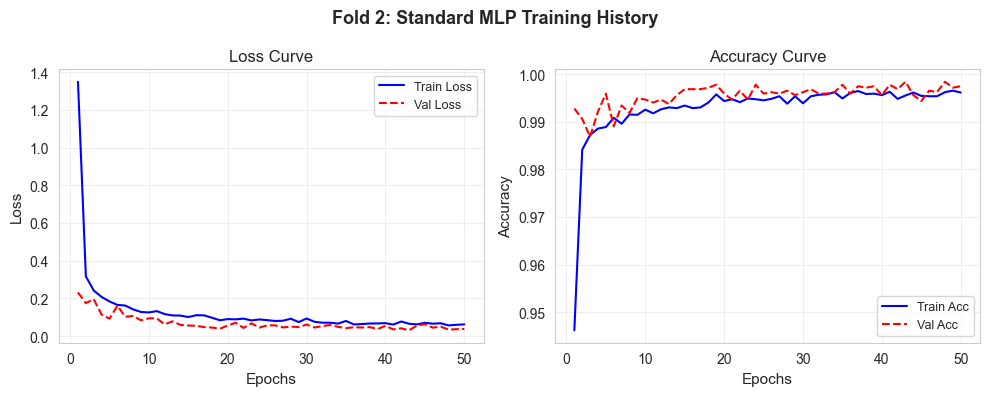

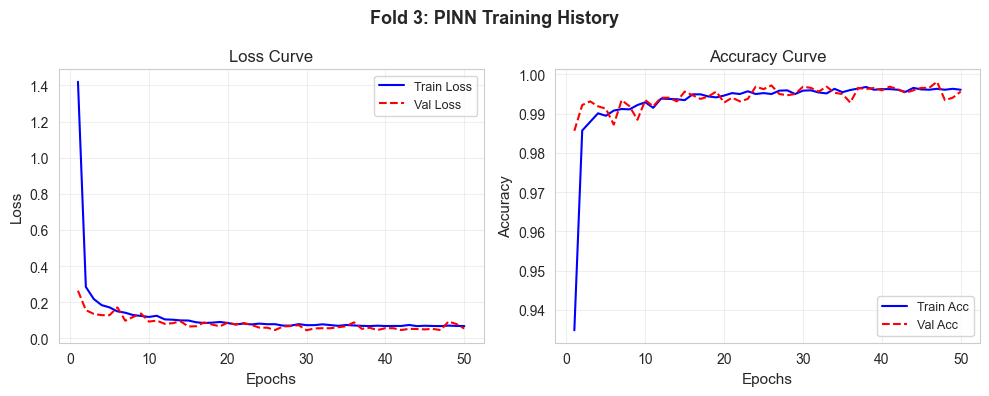

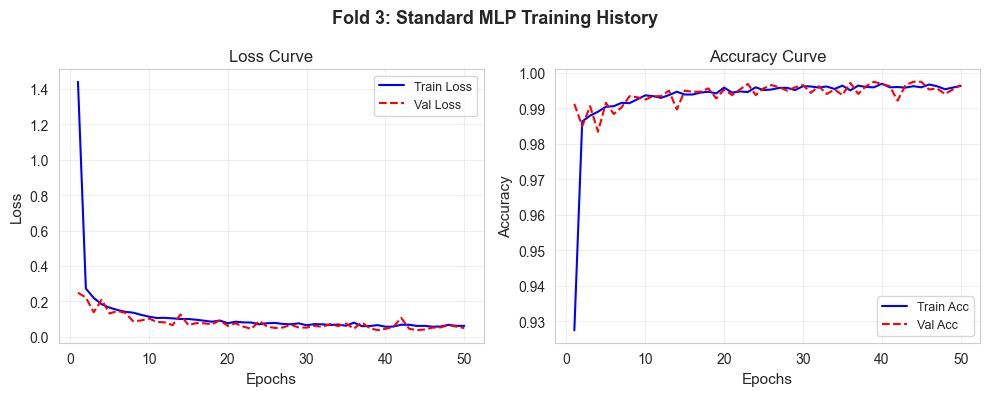

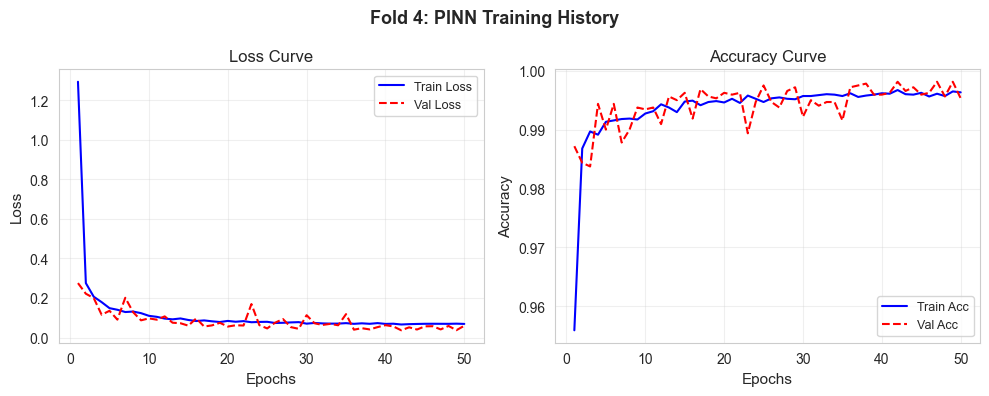

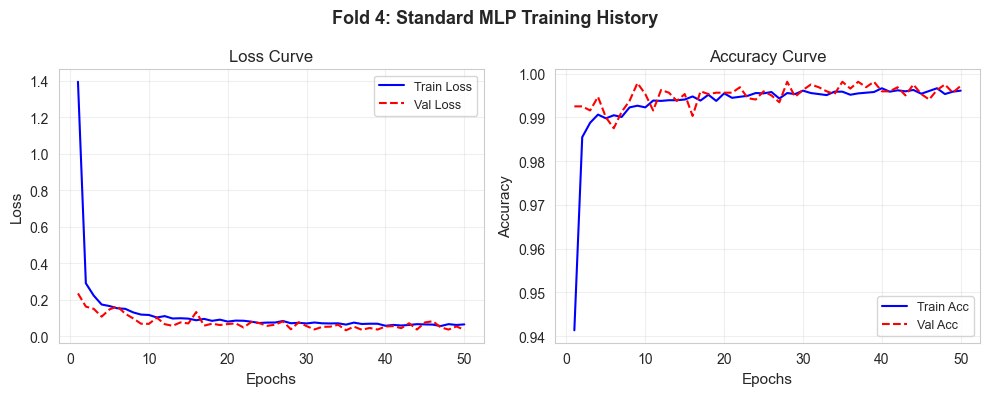

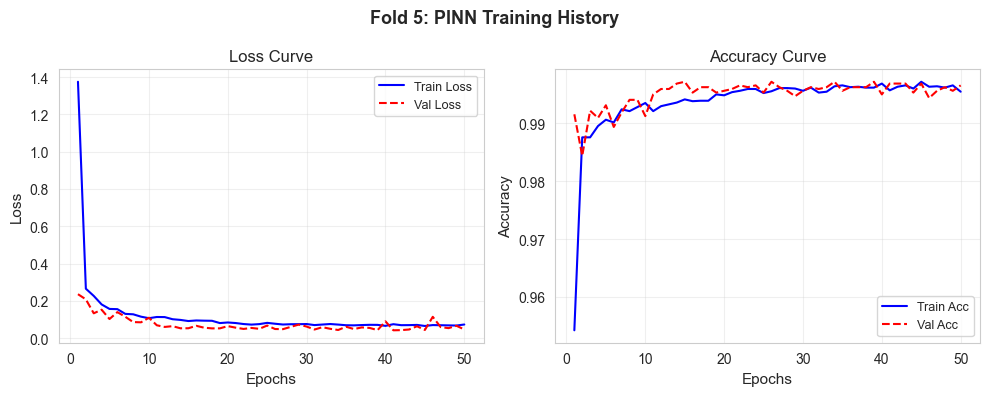

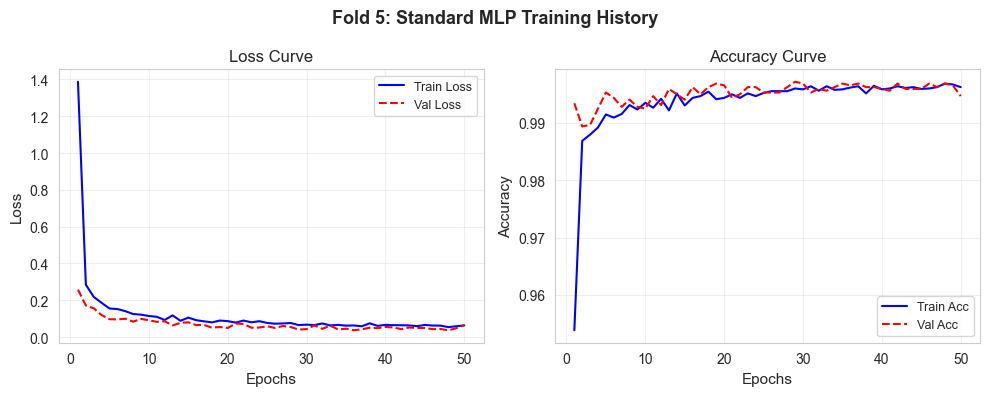

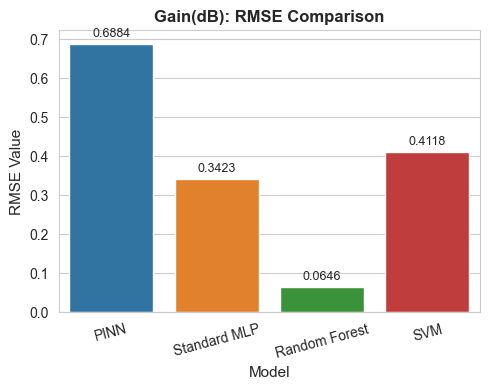

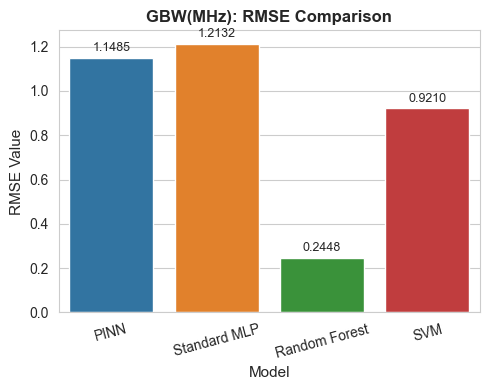

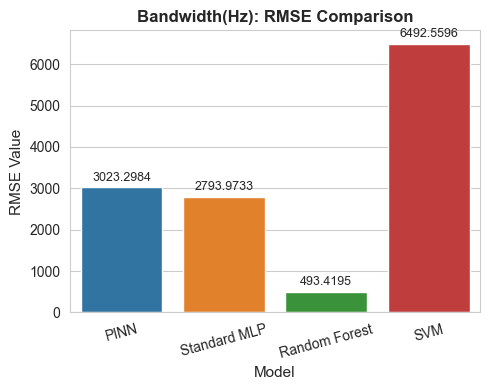

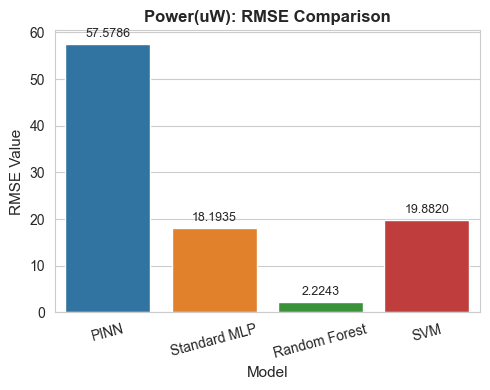

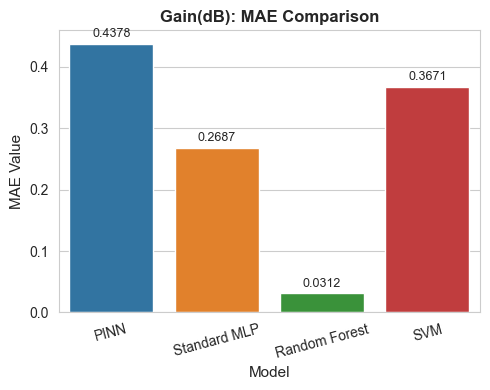

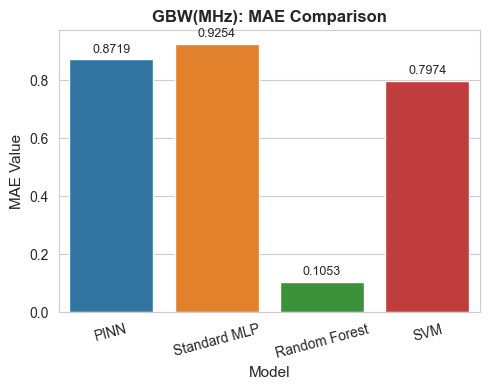

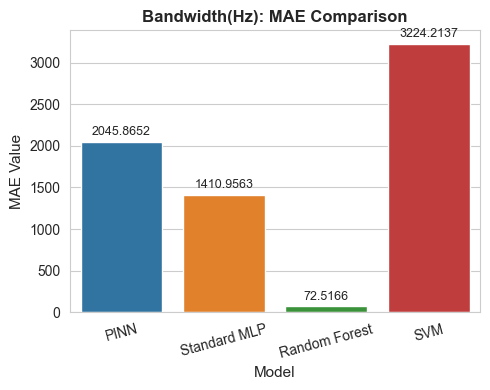

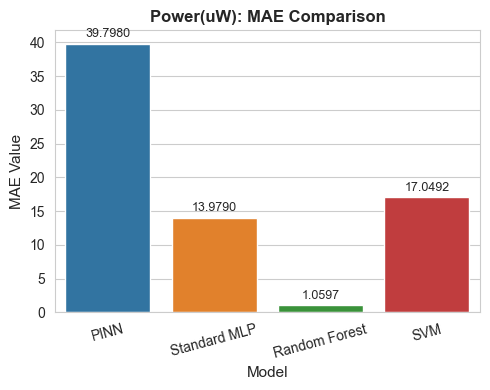

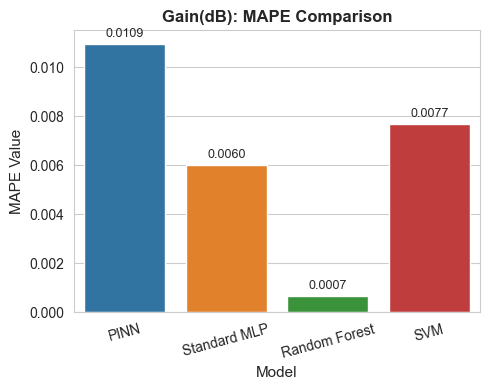

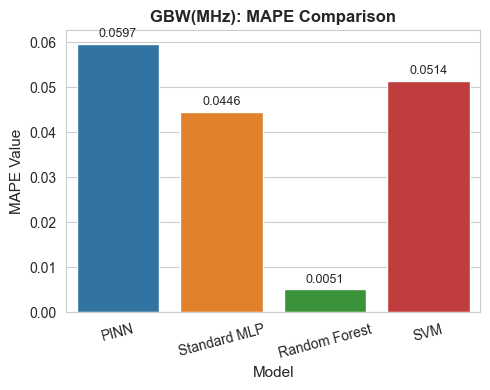

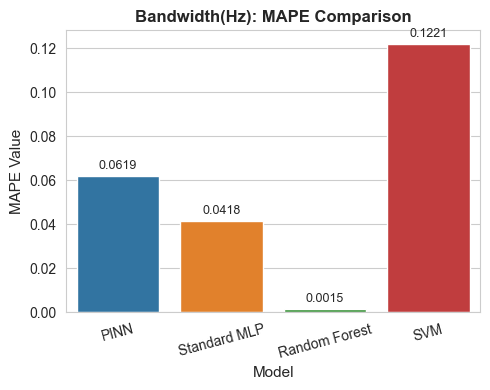

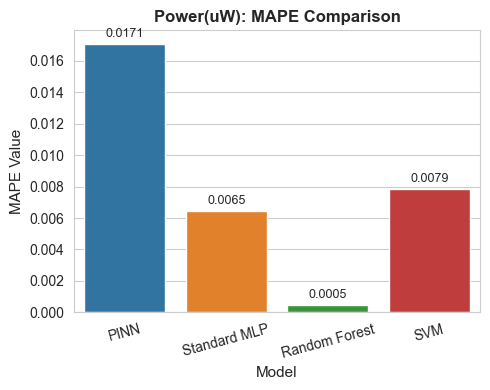

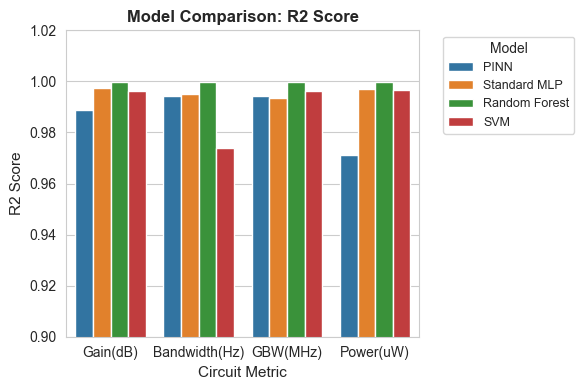

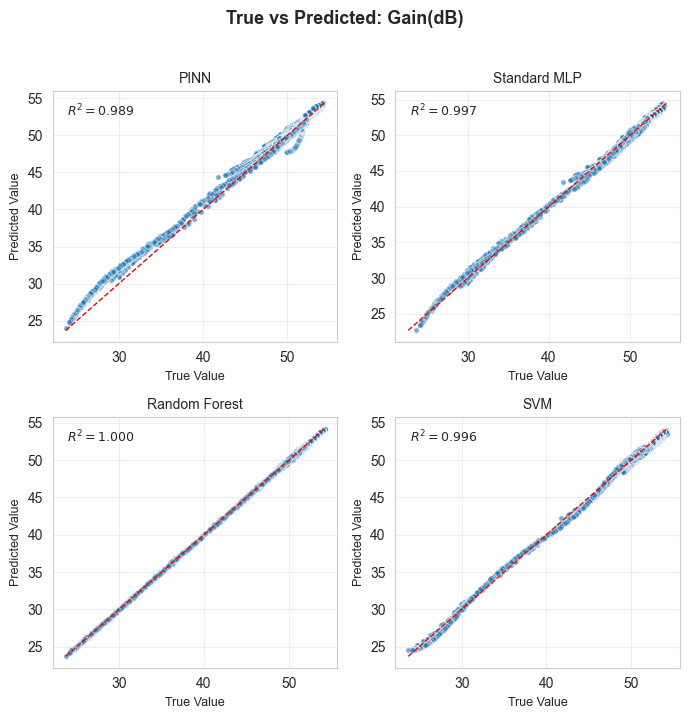

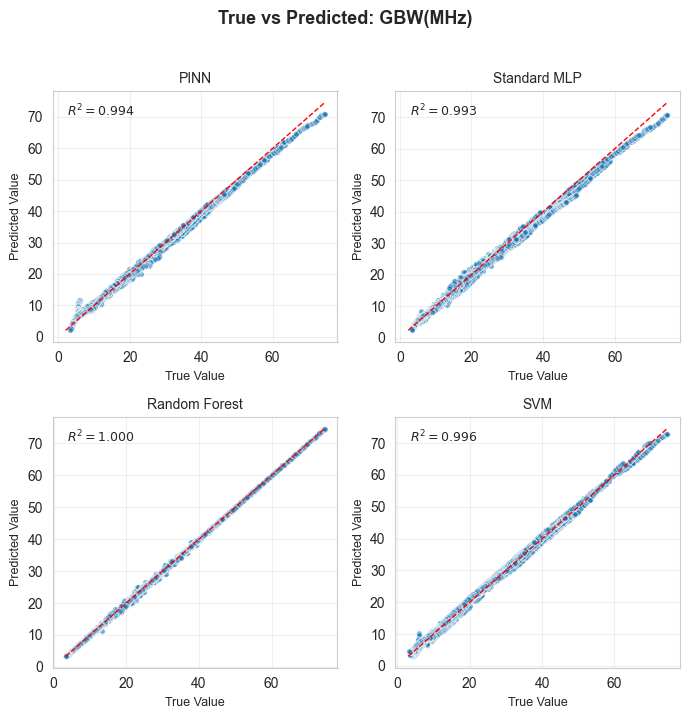

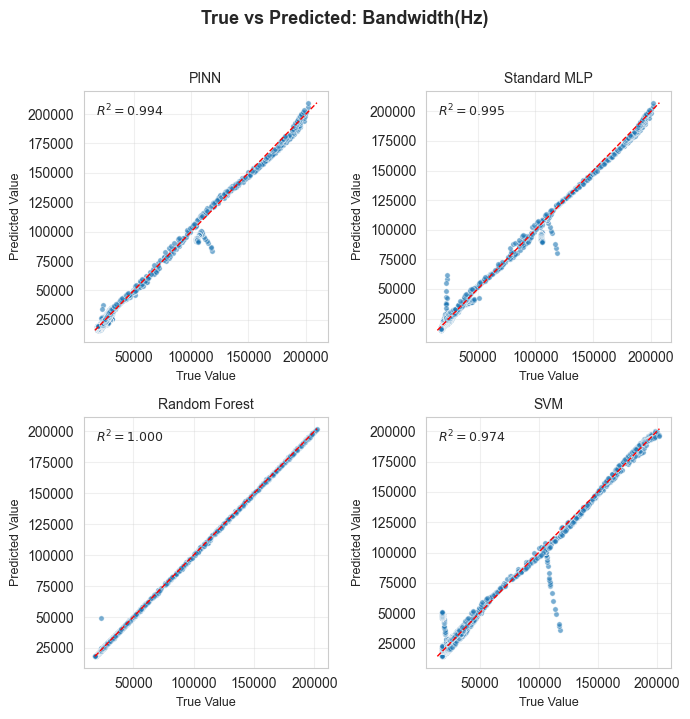

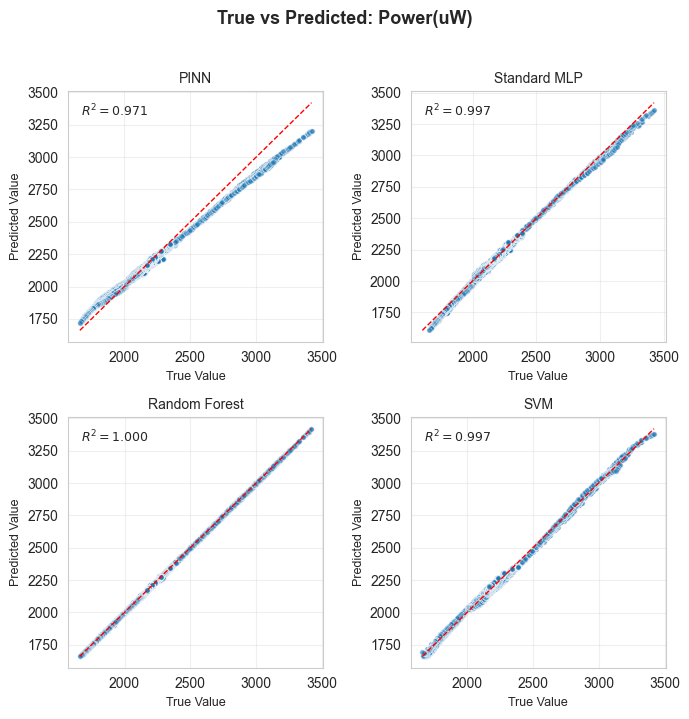

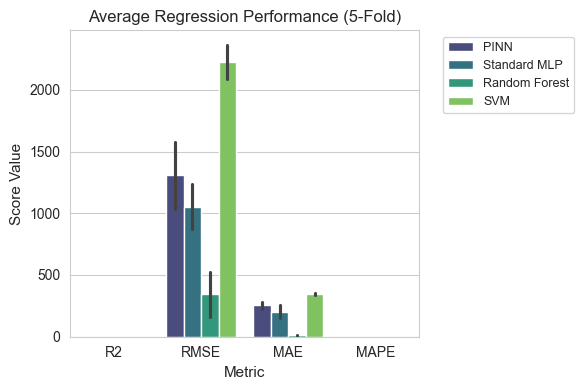

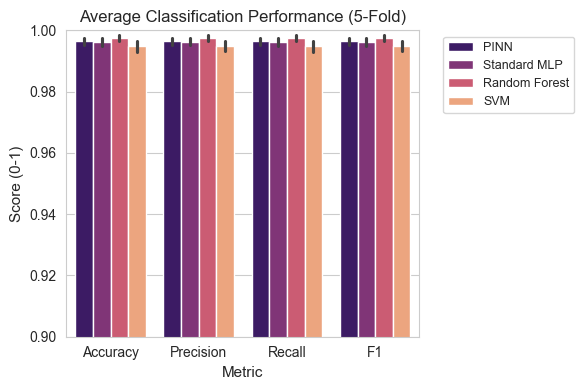

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# =========================================
# 1. Publication Plot Configuration
# =========================================
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
    'font.family': 'serif'
})
sns.set_style("whitegrid")

# Use the last fold's predictions for detailed plots
last_fold = all_fold_predictions[-1]
y_true_reg = last_fold['y_true_reg']
models = ['PINN', 'Standard MLP', 'Random Forest', 'SVM']
KEY_METRICS = ['Gain(dB)', 'GBW(MHz)', 'Bandwidth(Hz)', 'Power(uW)']

# =========================================
# 2. Training & Validation Curves (Per Fold)
# =========================================
# We plot the loss and accuracy curves for PINN and Standard MLP for each fold
for hist_data in training_histories:
    fold_num = hist_data['fold']
    for model_name in ['PINN', 'Standard MLP']:
        hist = hist_data[model_name]
        epochs = range(1, len(hist['train_loss']) + 1)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(f'Fold {fold_num}: {model_name} Training History', fontweight='bold')
        
        # Loss Curve
        ax1.plot(epochs, hist['train_loss'], 'b-', label='Train Loss')
        ax1.plot(epochs, hist['val_loss'], 'r--', label='Val Loss')
        ax1.set_title('Loss Curve')
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Accuracy Curve
        ax2.plot(epochs, hist['train_acc'], 'b-', label='Train Acc')
        ax2.plot(epochs, hist['val_acc'], 'r--', label='Val Acc')
        ax2.set_title('Accuracy Curve')
        ax2.set_xlabel('Epochs')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# =========================================
# 3. Detailed Metric Breakdown (Per Target)
# =========================================
detailed_results = []
for name in models:
    pred_reg, _ = last_fold[name]
    for i, target_name in enumerate(REGRESSION_TARGETS):
        y_true_col = y_true_reg[:, i]
        y_pred_col = pred_reg[:, i]
        detailed_results.append({
            'Model': name, 'Metric': target_name,
            'R2': r2_score(y_true_col, y_pred_col),
            'RMSE': np.sqrt(mean_squared_error(y_true_col, y_pred_col)),
            'MAE': mean_absolute_error(y_true_col, y_pred_col),
            'MAPE': mean_absolute_percentage_error(y_true_col, y_pred_col)
        })

df_breakdown = pd.DataFrame(detailed_results)
plot_df = df_breakdown[df_breakdown['Metric'].isin(KEY_METRICS)].copy()

# =========================================
# 4. Model Comparison Bar Plots (Separated by Metric)
# =========================================
score_types = ['RMSE', 'MAE', 'MAPE']
for score in score_types:
    for metric in KEY_METRICS:
        plt.figure(figsize=(5, 4))
        subset = plot_df[plot_df['Metric'] == metric]
        sns.barplot(data=subset, x='Model', y=score, palette='tab10')
        plt.title(f'{metric}: {score} Comparison', fontweight='bold')
        plt.xlabel('Model')
        plt.ylabel(f'{score} Value')
        plt.xticks(rotation=15)
        ax = plt.gca()
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.4f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 7), 
                        textcoords='offset points',
                        fontsize=9)
        plt.tight_layout()
        plt.show()

# R2 Comparison
plt.figure(figsize=(6, 4))
sns.barplot(data=plot_df, x='Metric', y='R2', hue='Model', palette='tab10')
plt.title('Model Comparison: R2 Score', fontweight='bold')
plt.xlabel('Circuit Metric')
plt.ylabel('R2 Score')
plt.ylim(0.9, 1.02)
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# =========================================
# 5. True vs Predicted Plots (2x2 Grid per Metric)
# =========================================
for target_name in KEY_METRICS:
    target_idx = REGRESSION_TARGETS.index(target_name)
    fig, axes = plt.subplots(2, 2, figsize=(7, 7))
    fig.suptitle(f'True vs Predicted: {target_name}', y=1.02, fontweight='bold')
    for i, name in enumerate(models):
        ax = axes[i // 2, i % 2]
        pred_reg, _ = last_fold[name]
        y_true_col = y_true_reg[:, target_idx]
        y_pred_col = pred_reg[:, target_idx]
        ax.scatter(y_true_col, y_pred_col, alpha=0.6, s=15, edgecolor='w', linewidth=0.5)
        min_val = min(y_true_col.min(), y_pred_col.min())
        max_val = max(y_true_col.max(), y_pred_col.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
        ax.set_title(f'{name}', fontsize=10)
        ax.set_xlabel('True Value', fontsize=9)
        ax.set_ylabel('Predicted Value', fontsize=9)
        ax.grid(True, alpha=0.3)
        r2_val = r2_score(y_true_col, y_pred_col)
        ax.text(0.05, 0.9, f'$R^2={r2_val:.3f}$', transform=ax.transAxes, fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

# =========================================
# 6. Overall Performance (K-Fold Average)
# =========================================
df_reg_melt = df_res_reg.melt(id_vars=['Model', 'Fold'], var_name='Metric', value_name='Score')
plt.figure(figsize=(6, 4))
sns.barplot(data=df_reg_melt, x='Metric', y='Score', hue='Model', palette='viridis', errorbar='sd')
plt.title("Average Regression Performance (5-Fold)")
plt.ylabel("Score Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

df_class_melt = df_res_class.melt(id_vars=['Model', 'Fold'], var_name='Metric', value_name='Score')
plt.figure(figsize=(6, 4))
sns.barplot(data=df_class_melt, x='Metric', y='Score', hue='Model', palette='magma', errorbar='sd')
plt.title("Average Classification Performance (5-Fold)")
plt.ylabel("Score (0-1)")
plt.ylim(0.9, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


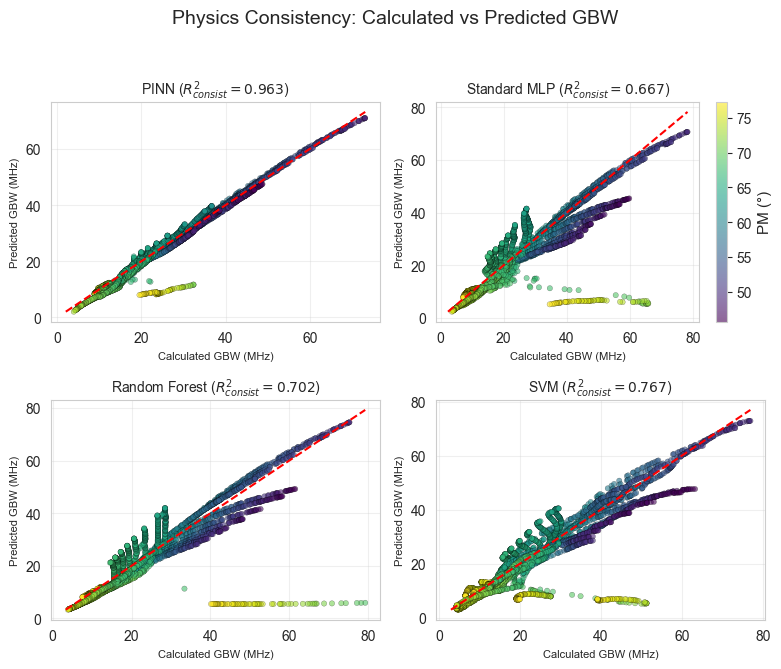

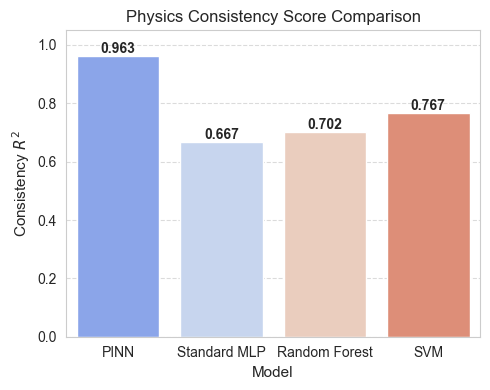


Physics Consistency Scores (R2 between Formula and Prediction):
        Model  Consistency_R2
         PINN        0.962744
 Standard MLP        0.667308
Random Forest        0.701815
          SVM        0.766718


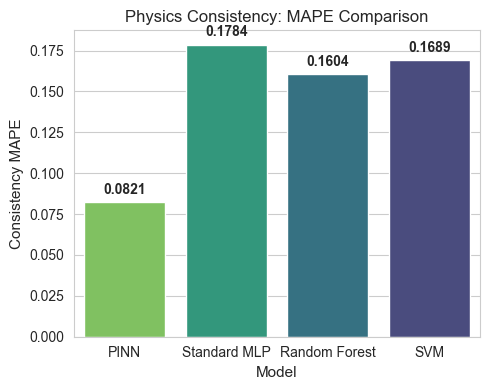


Physics Consistency MAPE (Error between Formula and Prediction):
        Model  Consistency_MAPE
         PINN          0.082099
 Standard MLP          0.178369
Random Forest          0.160439
          SVM          0.168900


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# =====================================================
# 1. Physics Consistency Configuration
# =====================================================
C1, C2, C3 = 11.28, 0.133, 1e-6  # Constants for formula
models = ['PINN', 'Standard MLP', 'Random Forest', 'SVM']
last_fold = all_fold_predictions[-1]

# Target indices
idx_gain = REGRESSION_TARGETS.index('Gain(dB)')
idx_bw   = REGRESSION_TARGETS.index('Bandwidth(Hz)')
idx_gbw  = REGRESSION_TARGETS.index('GBW(MHz)')
idx_pm   = REGRESSION_TARGETS.index('PM(degree)')

consistency_scores = []
consistency_mape_results = []

# =====================================================
# 2. Scatter Plots + Metric Calculation
# =====================================================
plt.figure(figsize=(8, 7))
plt.suptitle("Physics Consistency: Calculated vs Predicted GBW", fontsize=14)

for i, name in enumerate(models):

    ax = plt.subplot(2, 2, i + 1)

    pred_reg, _ = last_fold[name]

    # -------- Extract Predicted Outputs --------
    p_gain = pred_reg[:, idx_gain]
    p_bw   = pred_reg[:, idx_bw]
    p_gbw  = pred_reg[:, idx_gbw]
    p_pm   = pred_reg[:, idx_pm]

    # -------- Apply Physics Formula --------
    # GBW_MHz = 10^(Gain/20) * BW * (C1 - C2*PM) * 1e-6
    gain_lin = 10 ** (p_gain / 20.0)
    pm_corr = (C1 - (C2 * p_pm))
    x_calc = gain_lin * p_bw * pm_corr * C3  # physics calculated
    y_pred = p_gbw                           # model predicted

    # -------- Metrics --------
    r2_consist = r2_score(y_pred, x_calc)
    mape_consist = mean_absolute_percentage_error(x_calc, y_pred)

    consistency_scores.append({'Model': name, 'Consistency_R2': r2_consist})
    consistency_mape_results.append({'Model': name, 'Consistency_MAPE': mape_consist})

    # -------- Scatter Plot --------
    scatter = ax.scatter(
        x_calc, y_pred,
        c=p_pm,
        cmap='viridis',
        alpha=0.6,
        s=15,
        edgecolor='k',
        linewidth=0.2
    )

    # Ideal Line (perfect physics)
    lims = [
        min(x_calc.min(), y_pred.min()),
        max(x_calc.max(), y_pred.max())
    ]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal')

    ax.set_title(f"{name} ($R^2_{{consist}}={r2_consist:.3f}$)", fontsize=10)
    ax.set_xlabel("Calculated GBW (MHz)", fontsize=8)
    ax.set_ylabel("Predicted GBW (MHz)", fontsize=8)

    if i == 1:
        plt.colorbar(scatter, ax=ax, label='PM (°)')

    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# =====================================================
# 3. R² Consistency Bar Plot
# =====================================================
df_r2 = pd.DataFrame(consistency_scores)

plt.figure(figsize=(5, 4))
sns.barplot(data=df_r2, x='Model', y='Consistency_R2', palette='coolwarm')

plt.title("Physics Consistency Score Comparison", fontsize=12)
plt.ylabel("Consistency $R^2$")
plt.xlabel("Model")
plt.ylim(min(df_r2['Consistency_R2'].min() - 0.05, 0), 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(df_r2['Consistency_R2']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPhysics Consistency Scores (R2 between Formula and Prediction):")
print(df_r2.to_string(index=False))

# =====================================================
# 4. MAPE Consistency Bar Plot
# =====================================================
df_mape = pd.DataFrame(consistency_mape_results)

plt.figure(figsize=(5, 4))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_mape, x='Model', y='Consistency_MAPE', palette='viridis_r')

plt.title("Physics Consistency: MAPE Comparison", fontsize=12)
plt.ylabel("Consistency MAPE")
plt.xlabel("Model")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 9),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print("\nPhysics Consistency MAPE (Error between Formula and Prediction):")
print(df_mape.to_string(index=False))


In [4]:
import pandas as pd
import numpy as np
from tabulate import tabulate

# ==========================================
# 1. Physics Violation Index Configuration
# ==========================================
# Using the same constants and indices from Block 3
C1, C2, C3 = 11.28, 0.133, 1e-6
models = ['PINN', 'Standard MLP', 'Random Forest', 'SVM']
last_fold = all_fold_predictions[-1]

idx_gain = REGRESSION_TARGETS.index('Gain(dB)')
idx_bw = REGRESSION_TARGETS.index('Bandwidth(Hz)')
idx_gbw = REGRESSION_TARGETS.index('GBW(MHz)')
idx_pm = REGRESSION_TARGETS.index('PM(degree)')

violation_metrics = []

# ==========================================
# 2. Calculate Violation Metrics per Model
# ==========================================
for name in models:
    pred_reg, _ = last_fold[name]
    
    # Extract Predicted Features
    p_gain = pred_reg[:, idx_gain]
    p_bw = pred_reg[:, idx_bw]
    p_gbw = pred_reg[:, idx_gbw]
    p_pm = pred_reg[:, idx_pm]
    
    # Apply Custom Formula: GBW_calc = 10^(Gain/20) * BW * (C1 - C2*PM) * 1e-6
    gain_lin = 10 ** (p_gain / 20.0)
    pm_corr = (C1 - (C2 * p_pm))
    x_calc = gain_lin * p_bw * pm_corr * C3
    y_pred = p_gbw
    
    # Calculate Relative Violation (Error)
    # Violation = |(Predicted - Calculated) / Calculated|
    # We use a small epsilon to avoid division by zero
    relative_violation = np.abs((y_pred - x_calc) / (x_calc + 1e-8))
    
    # Metrics
    mean_violation = np.mean(relative_violation)
    std_violation = np.std(relative_violation)
    max_violation = np.max(relative_violation)
    
    # Percentage of samples within ±10% (0.10) relative error
    within_10_percent = np.mean(relative_violation <= 0.10) * 100
    
    violation_metrics.append({
        'Model': name,
        'Mean Violation': f"{mean_violation:.4f}",
        'Std. Dev.': f"{std_violation:.4f}",
        'Max Violation': f"{max_violation:.4f}",
        '% Samples Within ±10%': f"{within_10_percent:.2f}%"
    })

# ==========================================
# 3. Display the Violation Index Table
# ==========================================
df_violation = pd.DataFrame(violation_metrics)

print("\n" + "="*85)
print("PHYSICS VIOLATION INDEX (Based on GBW Consistency Formula)")
print("="*85)
print(tabulate(df_violation, headers='keys', tablefmt='grid', showindex=False))
print("="*85)
print("Note: Violation is calculated as the relative error between the model's predicted GBW")
print("and the value calculated via the physics formula. Lower values indicate better consistency.")



PHYSICS VIOLATION INDEX (Based on GBW Consistency Formula)
+---------------+------------------+-------------+-----------------+-------------------------+
| Model         |   Mean Violation |   Std. Dev. |   Max Violation | % Samples Within ±10%   |
+===============+==================+=============+=================+=========================+
| PINN          |           0.0821 |      0.1095 |          0.6512 | 78.09%                  |
+---------------+------------------+-------------+-----------------+-------------------------+
| Standard MLP  |           0.1784 |      0.1608 |          0.9178 | 35.69%                  |
+---------------+------------------+-------------+-----------------+-------------------------+
| Random Forest |           0.1604 |      0.1498 |          0.9251 | 40.38%                  |
+---------------+------------------+-------------+-----------------+-------------------------+
| SVM           |           0.1689 |      0.1713 |          0.898  | 42.69%          

In [5]:
pip install tabulate

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from tabulate import tabulate

# ==========================================
# 1. Performance Tables Configuration
# ==========================================
# Use all folds so each reported metric is mean ± std across K-fold runs
models = ['PINN', 'Standard MLP', 'Random Forest', 'SVM']
KEY_METRICS = ['Gain(dB)', 'Bandwidth(Hz)', 'GBW(MHz)', 'Power(uW)']

# Helper to get metric index
metric_indices = {m: REGRESSION_TARGETS.index(m) for m in KEY_METRICS}

# ==========================================
# 2. Calculate Metrics per Fold, Model, and Metric
# ==========================================
fold_results = []
for fold_data in all_fold_predictions:
    y_true_reg = fold_data['y_true_reg']
    for name in models:
        pred_reg, _ = fold_data[name]
        for metric in KEY_METRICS:
            idx = metric_indices[metric]
            y_true = y_true_reg[:, idx]
            y_pred = pred_reg[:, idx]
            fold_results.append({
                'Model': name,
                'Metric': metric,
                'MAE': mean_absolute_error(y_true, y_pred),
                'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
                'R2': r2_score(y_true, y_pred),
            })

df_all_folds = pd.DataFrame(fold_results)
df_agg = (
    df_all_folds.groupby(['Model', 'Metric'])[['MAE', 'RMSE', 'R2']]
    .agg(['mean', 'std'])
    .reset_index()
)
df_agg.columns = ['Model', 'Metric', 'MAE_mean', 'MAE_std', 'RMSE_mean', 'RMSE_std', 'R2_mean', 'R2_std']

def fmt_mean_std(mean_val, std_val):
    return f"{mean_val:.4f} ± {std_val:.4f}"

mae_data = []
rmse_data = []
r2_data = []
for name in models:
    row_mae = {'Model': name}
    row_rmse = {'Model': name}
    row_r2 = {'Model': name}
    for metric in KEY_METRICS:
        subset = df_agg[(df_agg['Model'] == name) & (df_agg['Metric'] == metric)].iloc[0]
        row_mae[f'{metric} MAE'] = fmt_mean_std(subset['MAE_mean'], subset['MAE_std'])
        row_rmse[f'{metric} RMSE'] = fmt_mean_std(subset['RMSE_mean'], subset['RMSE_std'])
        row_r2[f'{metric} R2'] = fmt_mean_std(subset['R2_mean'], subset['R2_std'])
    mae_data.append(row_mae)
    rmse_data.append(row_rmse)
    r2_data.append(row_r2)

# ==========================================
# 3. Display Tables for Word
# ==========================================
df_mae = pd.DataFrame(mae_data)
df_rmse = pd.DataFrame(rmse_data)
df_r2 = pd.DataFrame(r2_data)

print("\n" + "="*80)
print("TABLE 1: MEAN ± STD MEAN ABSOLUTE ERROR (MAE) COMPARISON")
print("="*80)
print(tabulate(df_mae, headers='keys', tablefmt='grid', showindex=False))

print("\n" + "="*80)
print("TABLE 2: MEAN ± STD ROOT MEAN SQUARE ERROR (RMSE) COMPARISON")
print("="*80)
print(tabulate(df_rmse, headers='keys', tablefmt='grid', showindex=False))

print("\n" + "="*80)
print("TABLE 3: MEAN ± STD R-SQUARED (R2) SCORE COMPARISON")
print("="*80)
print(tabulate(df_r2, headers='keys', tablefmt='grid', showindex=False))
print("\n" + "="*80)
print("Tip: You can copy these tables directly into Microsoft Word.")
print("="*80)


TABLE 1: MEAN ± STD MEAN ABSOLUTE ERROR (MAE) COMPARISON
+---------------+-----------------+----------------------+-----------------+------------------+
| Model         | Gain(dB) MAE    | Bandwidth(Hz) MAE    | GBW(MHz) MAE    | Power(uW) MAE    |
+===============+=================+======================+=================+==================+
| PINN          | 0.4833 ± 0.0978 | 2242.6489 ± 257.7727 | 0.9321 ± 0.1190 | 33.6891 ± 3.6237 |
+---------------+-----------------+----------------------+-----------------+------------------+
| Standard MLP  | 0.2710 ± 0.0471 | 1808.9738 ± 484.7171 | 0.8109 ± 0.1114 | 12.9773 ± 2.8249 |
+---------------+-----------------+----------------------+-----------------+------------------+
| Random Forest | 0.0301 ± 0.0012 | 91.2463 ± 15.8883    | 0.1032 ± 0.0025 | 1.0425 ± 0.0335  |
+---------------+-----------------+----------------------+-----------------+------------------+
| SVM           | 0.3670 ± 0.0043 | 3123.2485 ± 78.9055  | 0.8016 ± 0.0086 | 1

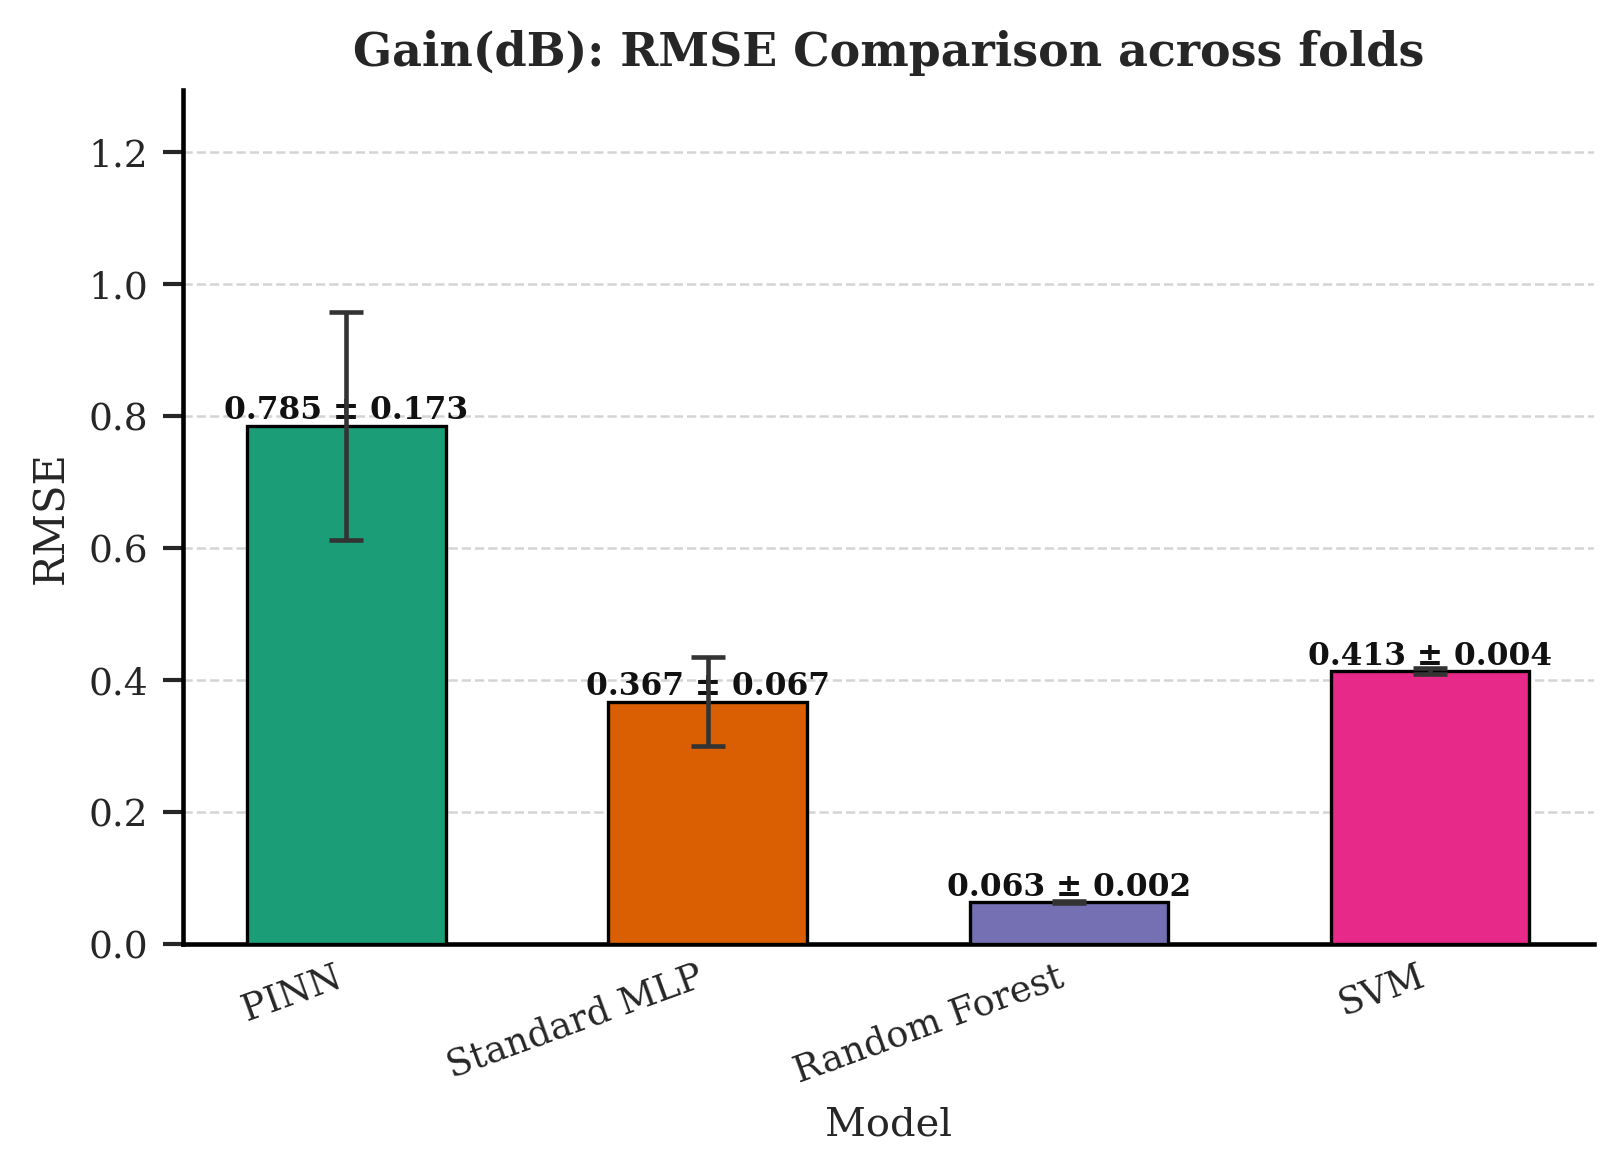

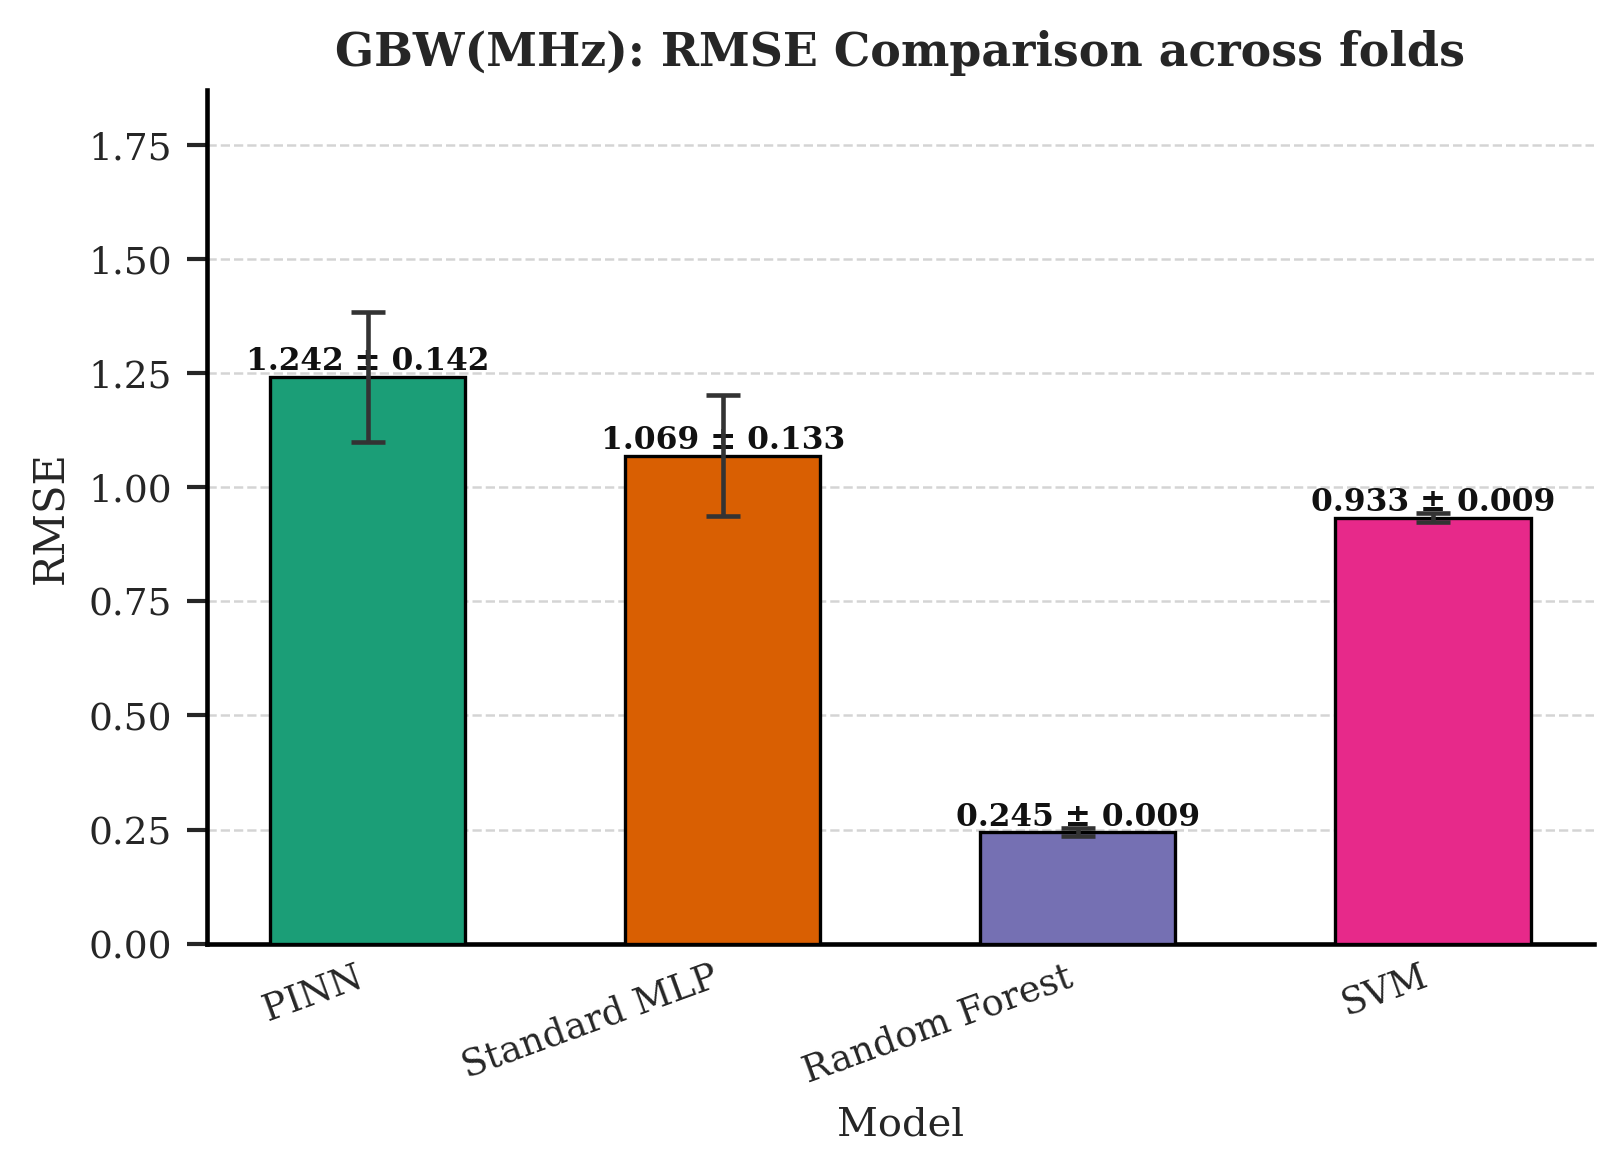

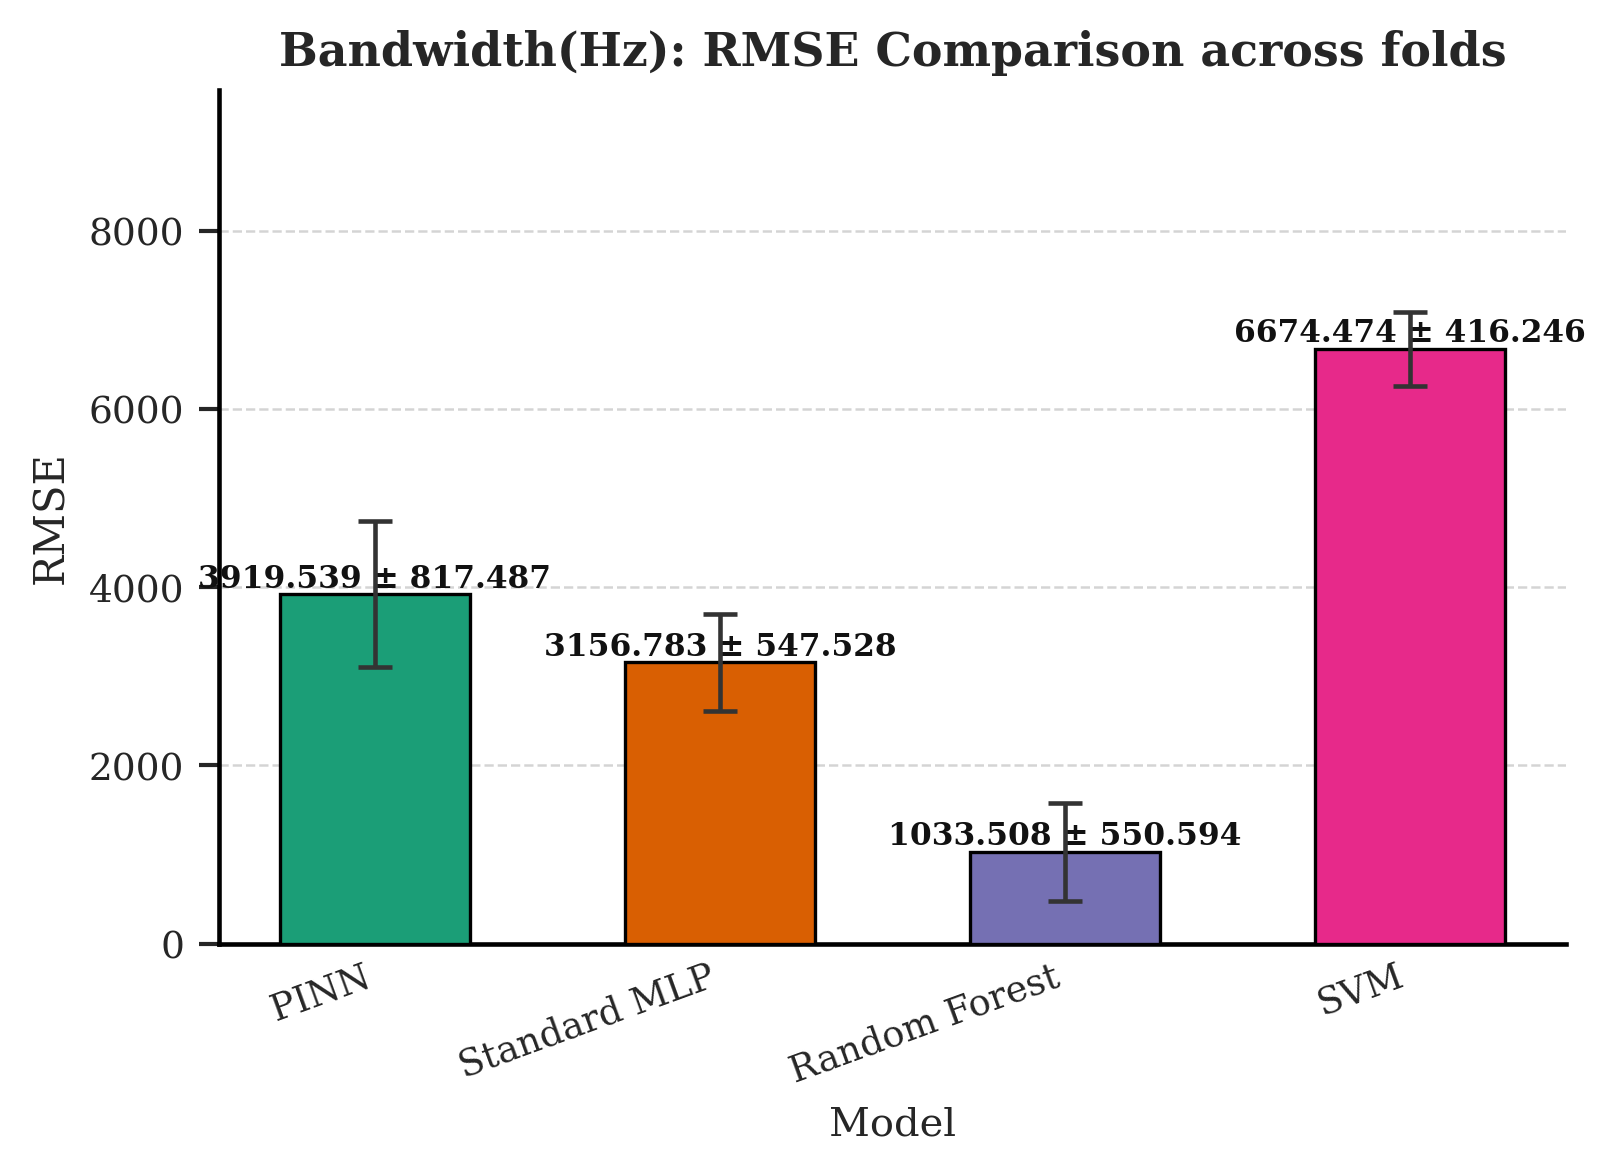

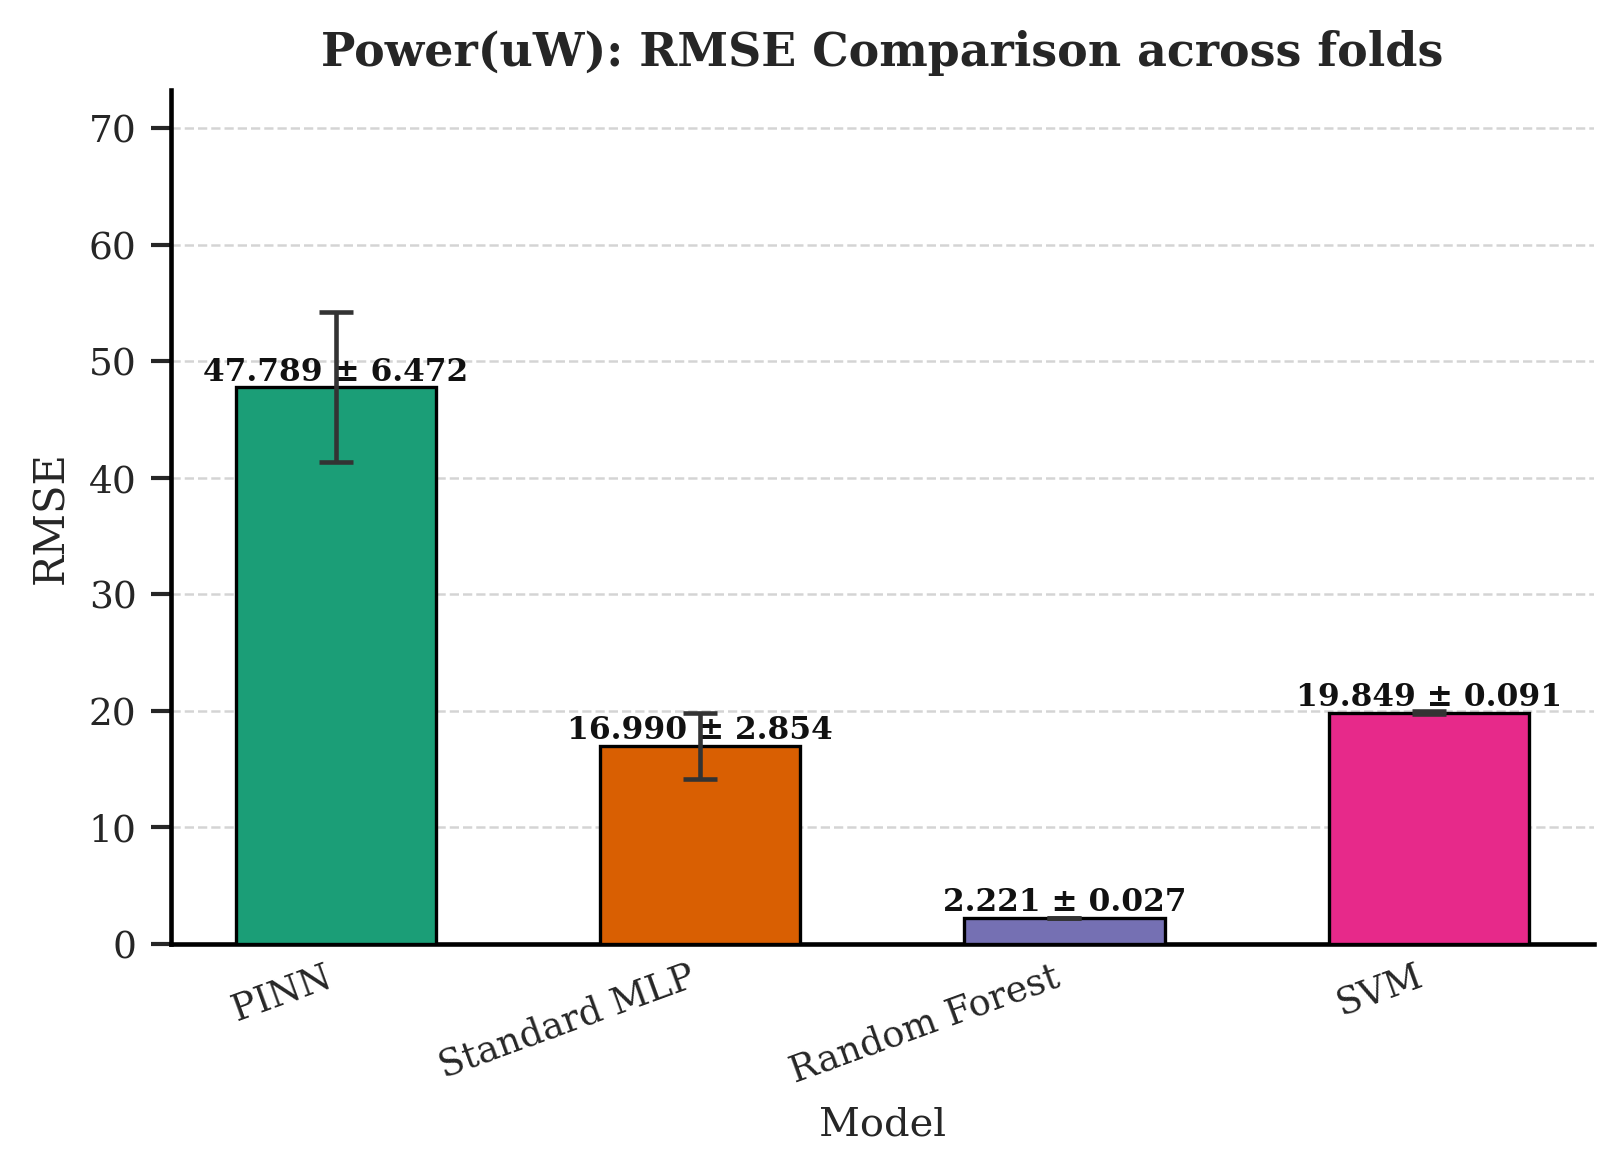

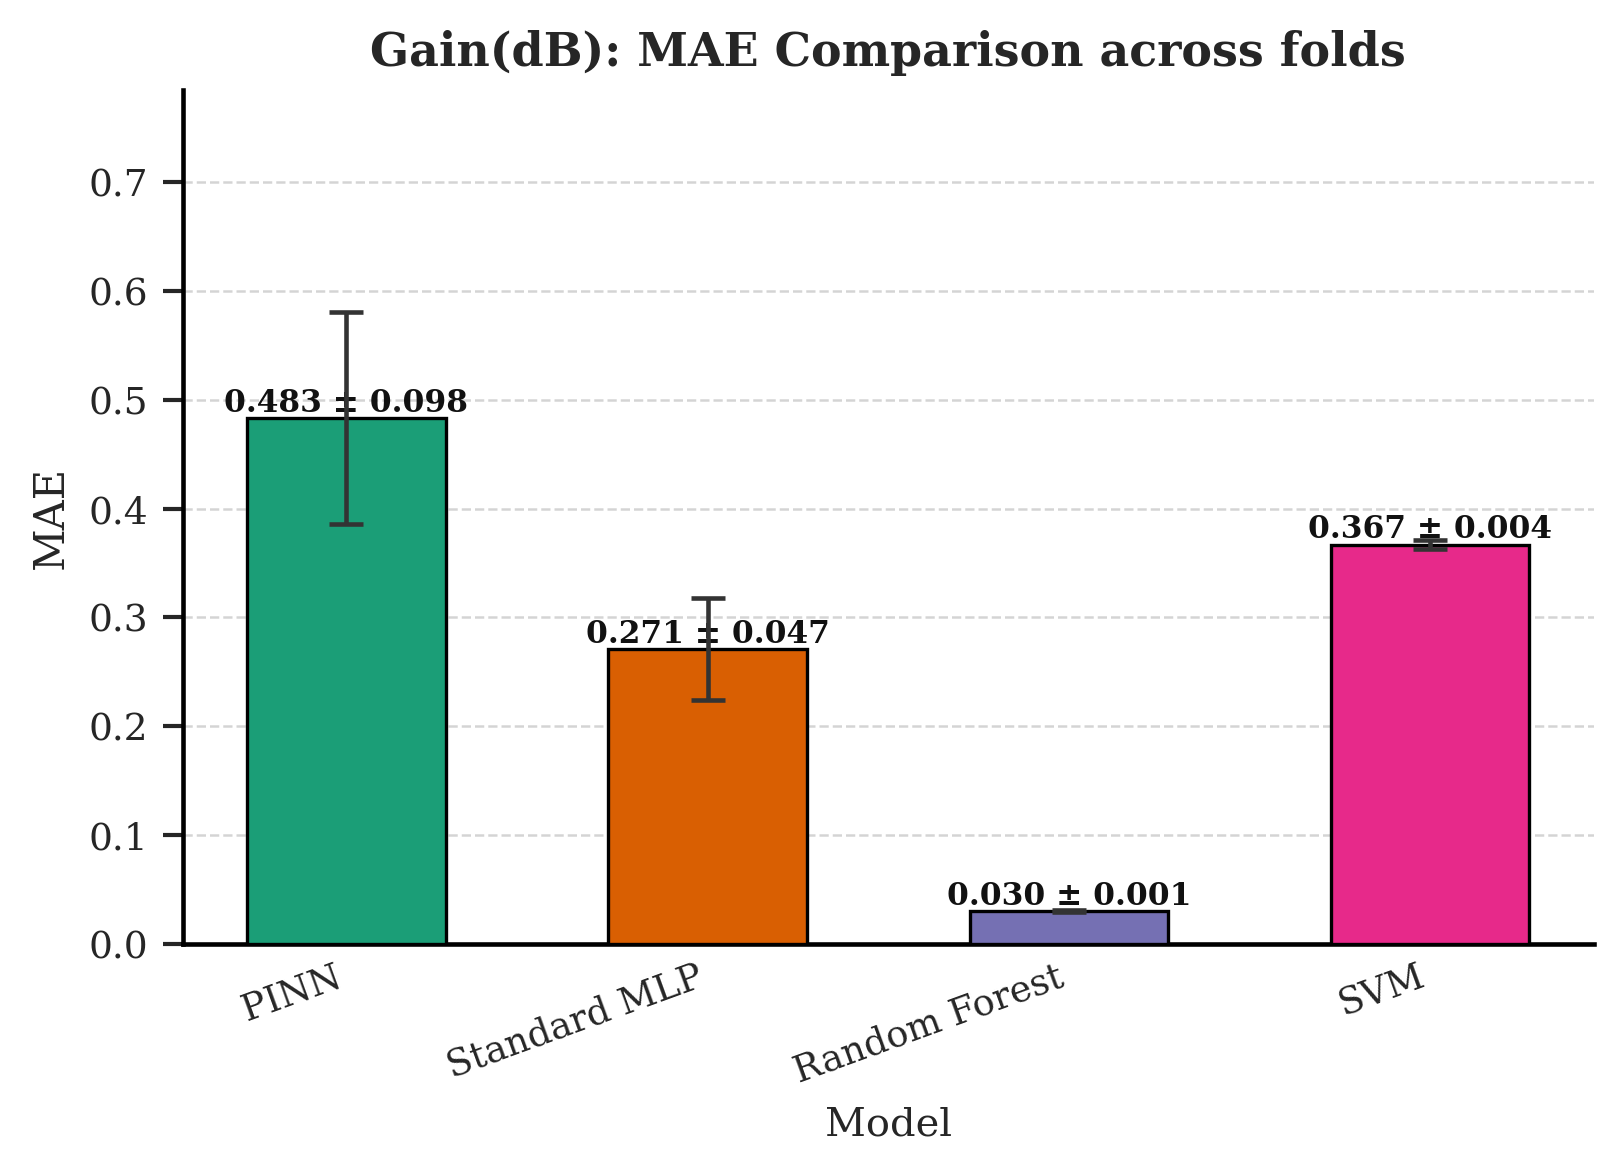

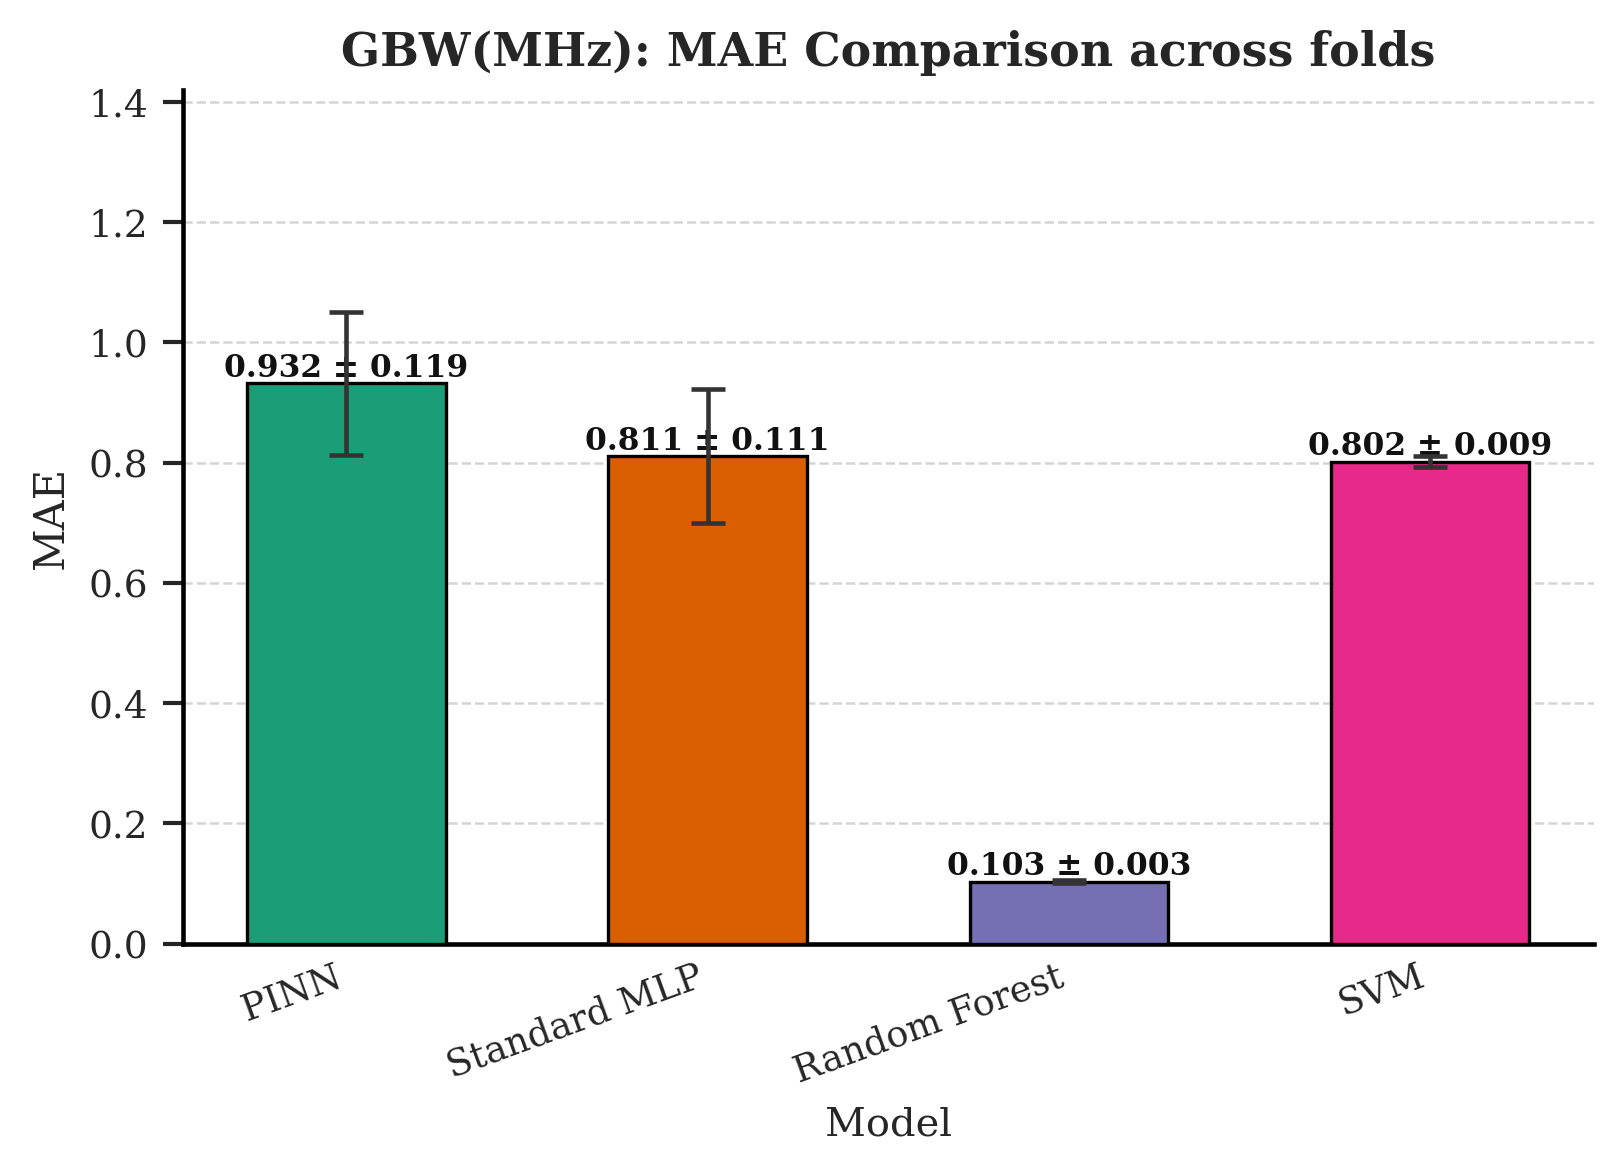

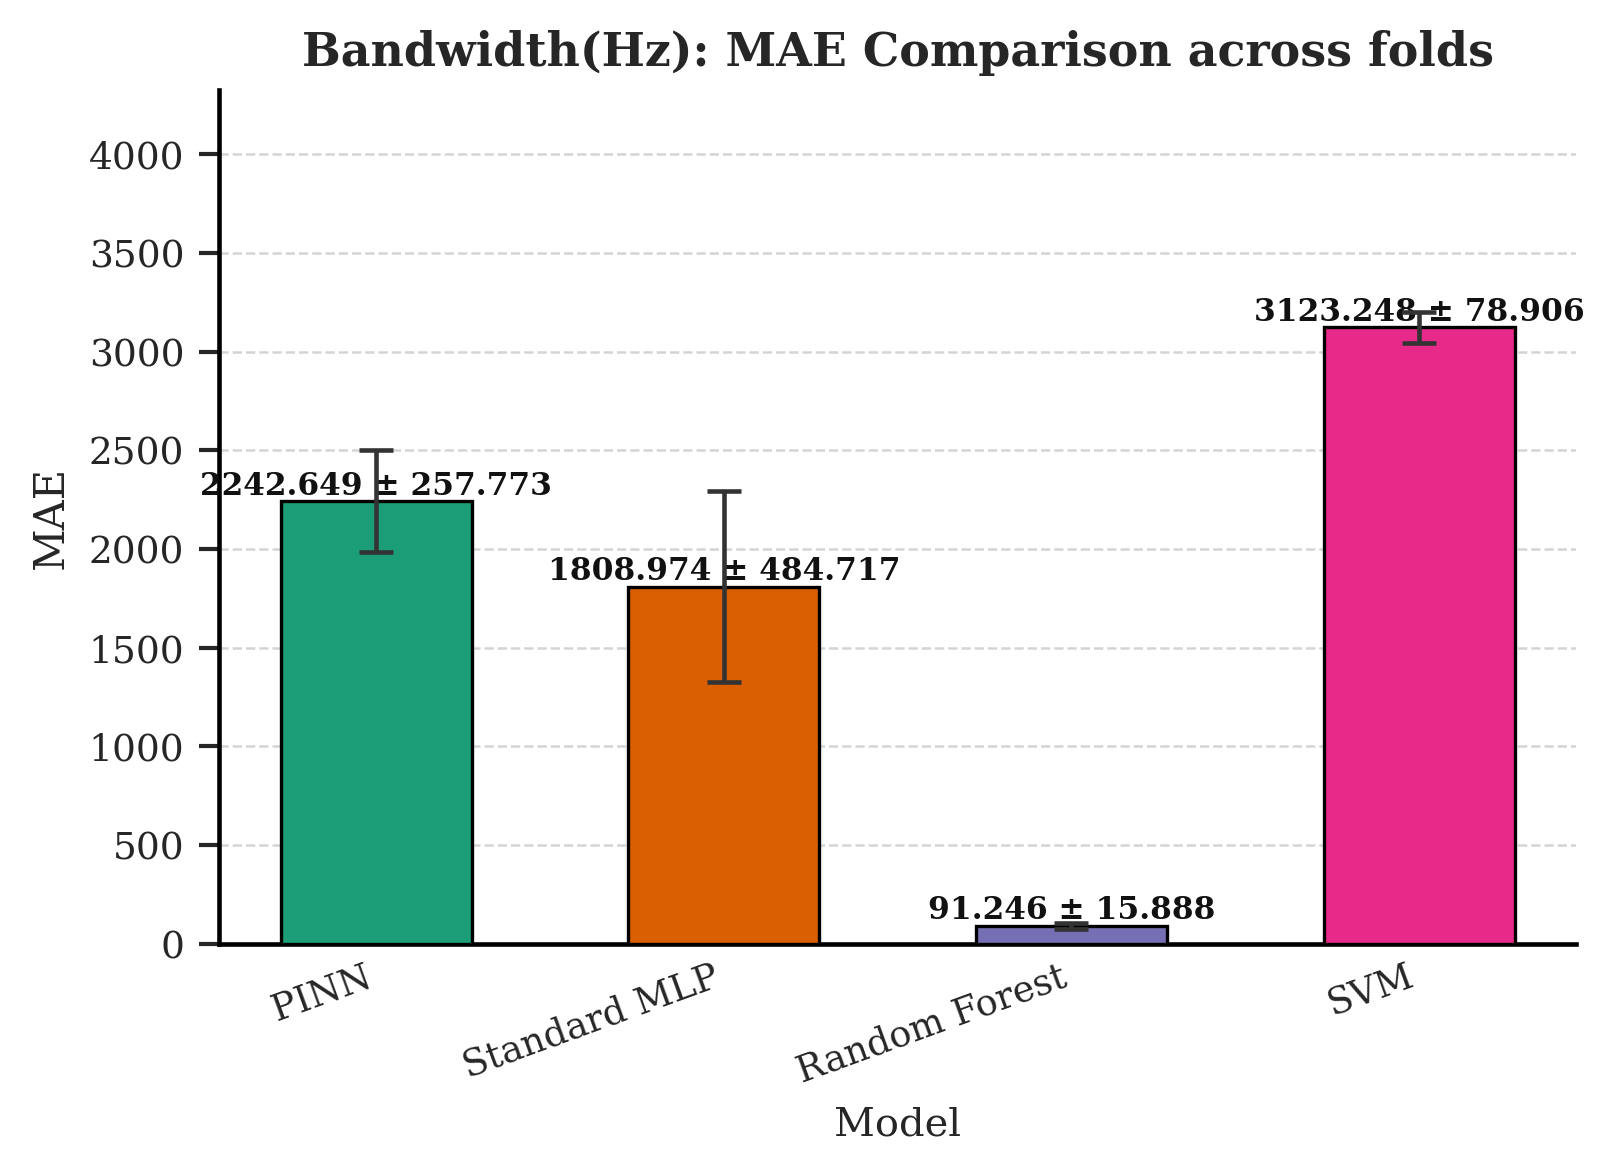

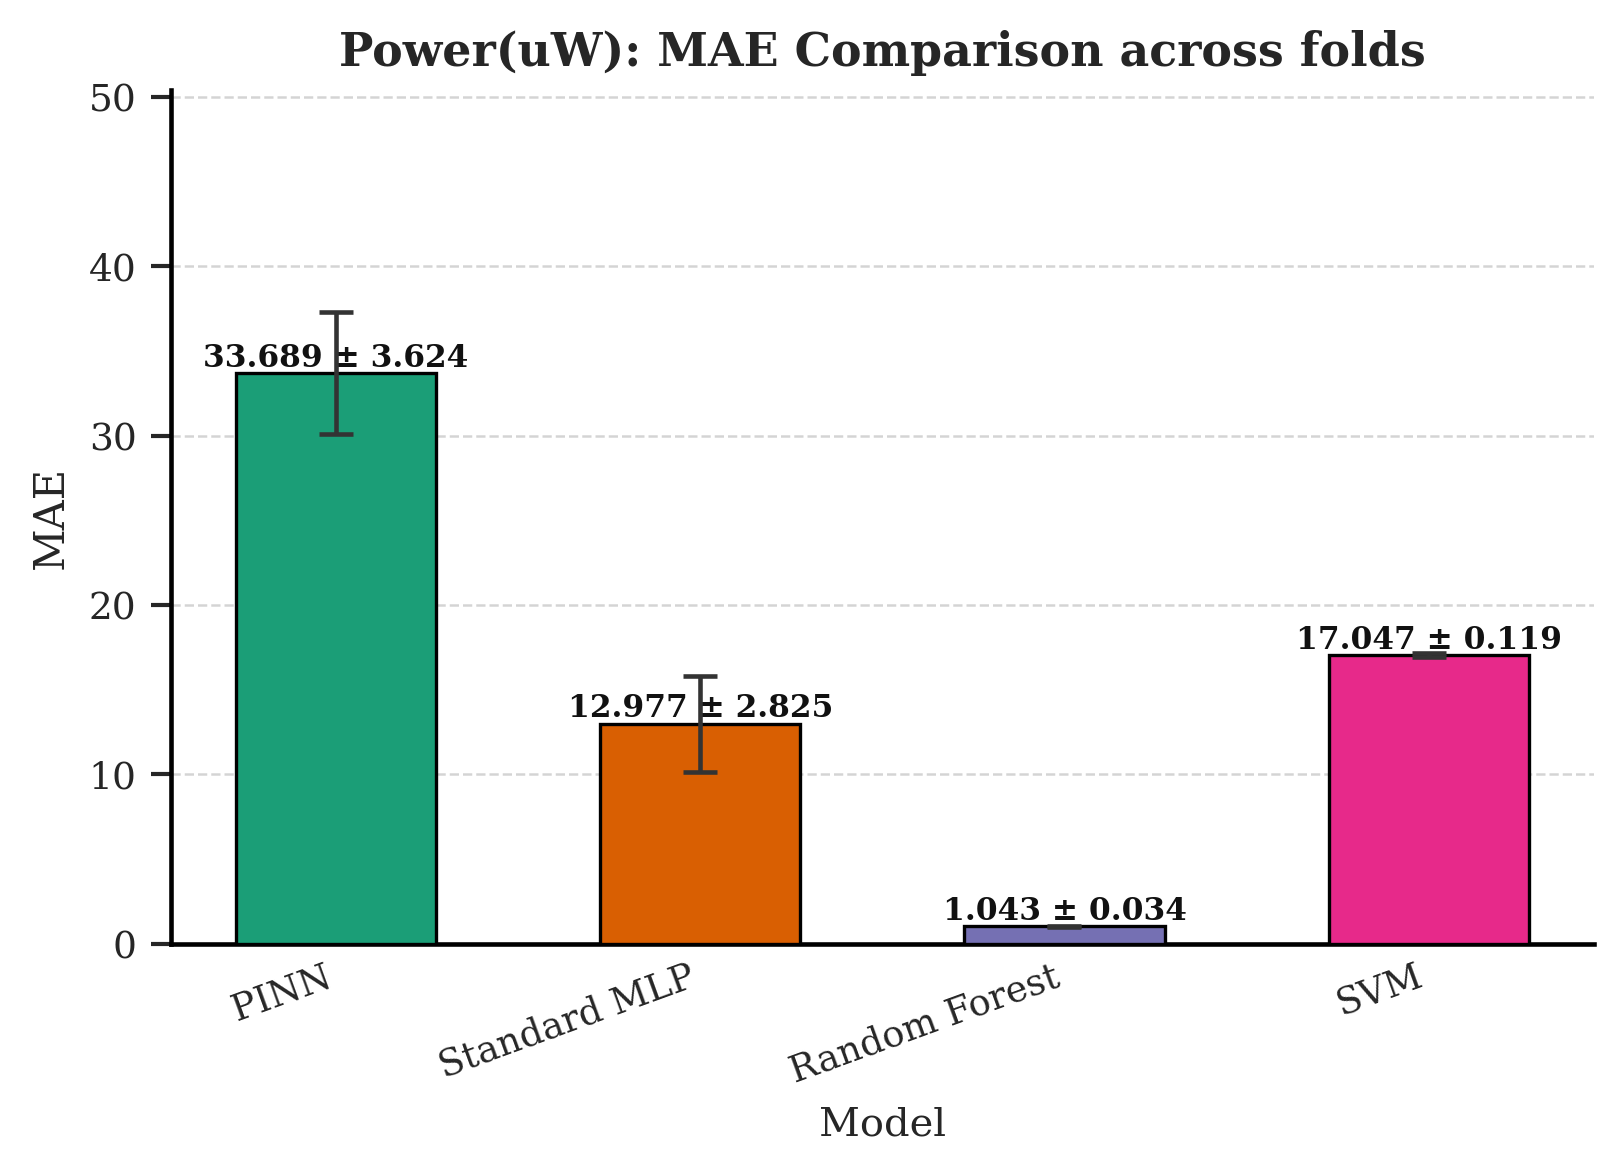

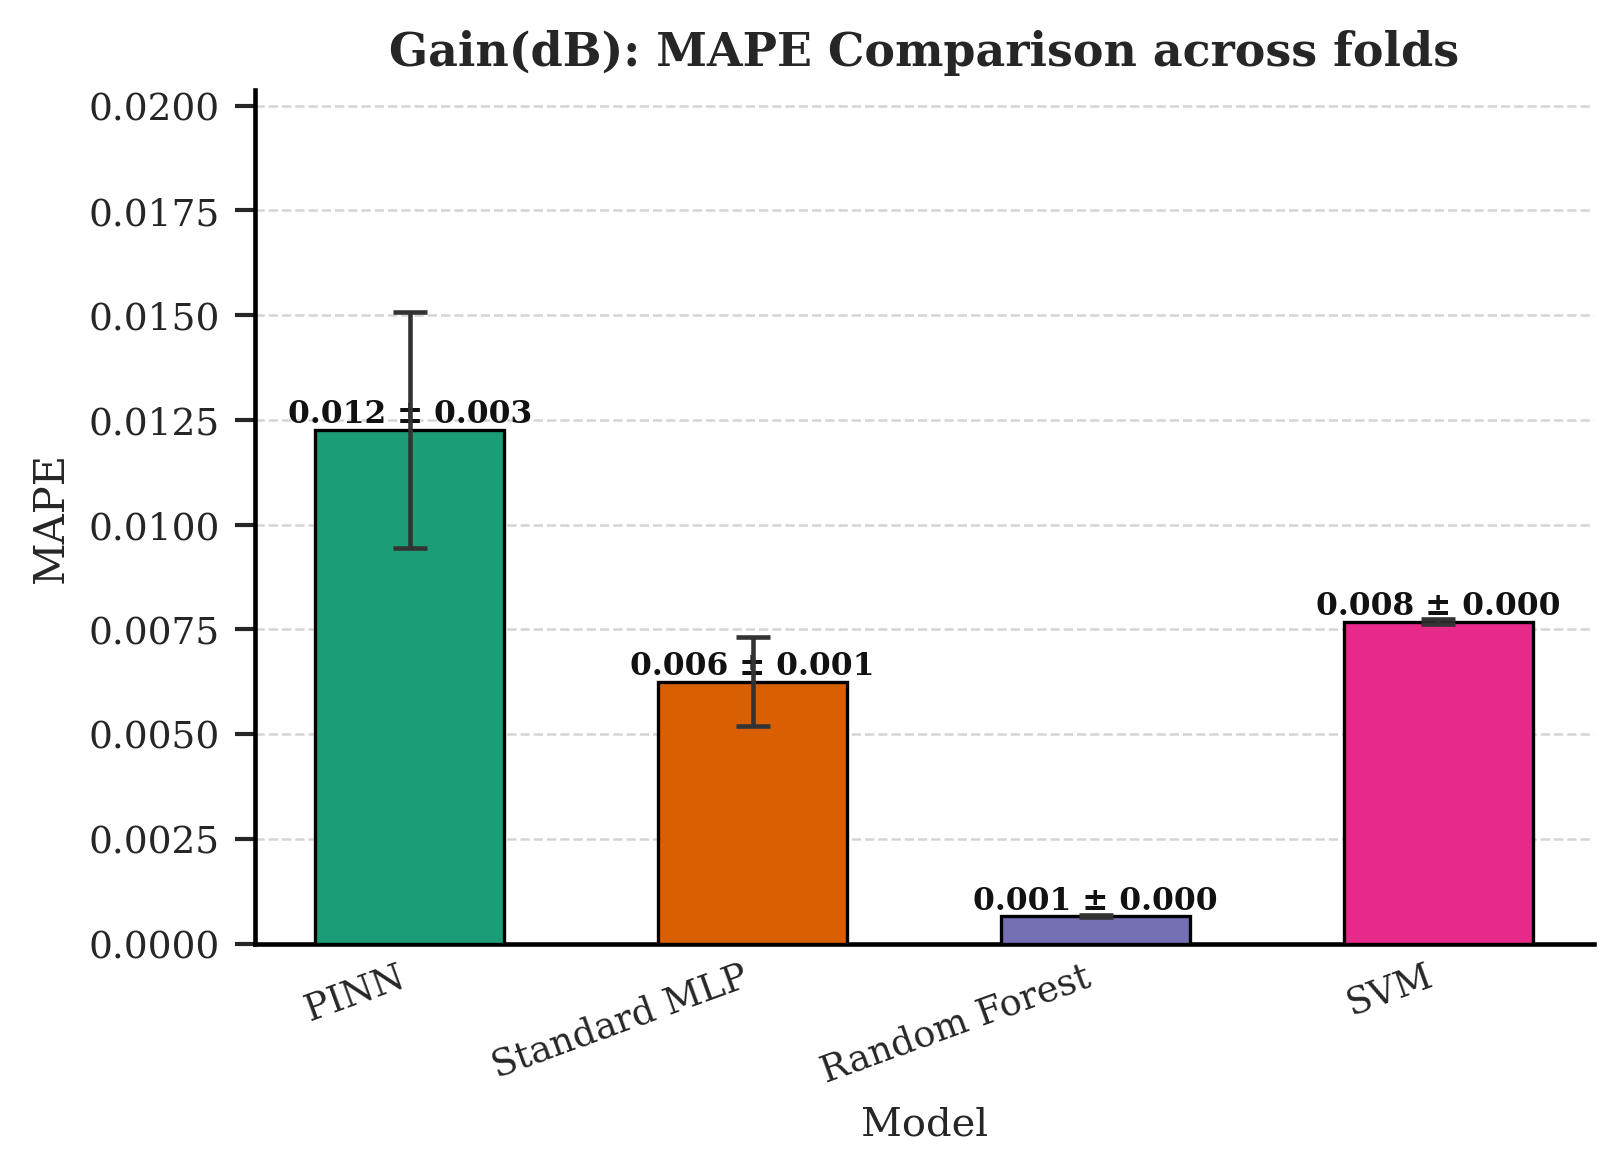

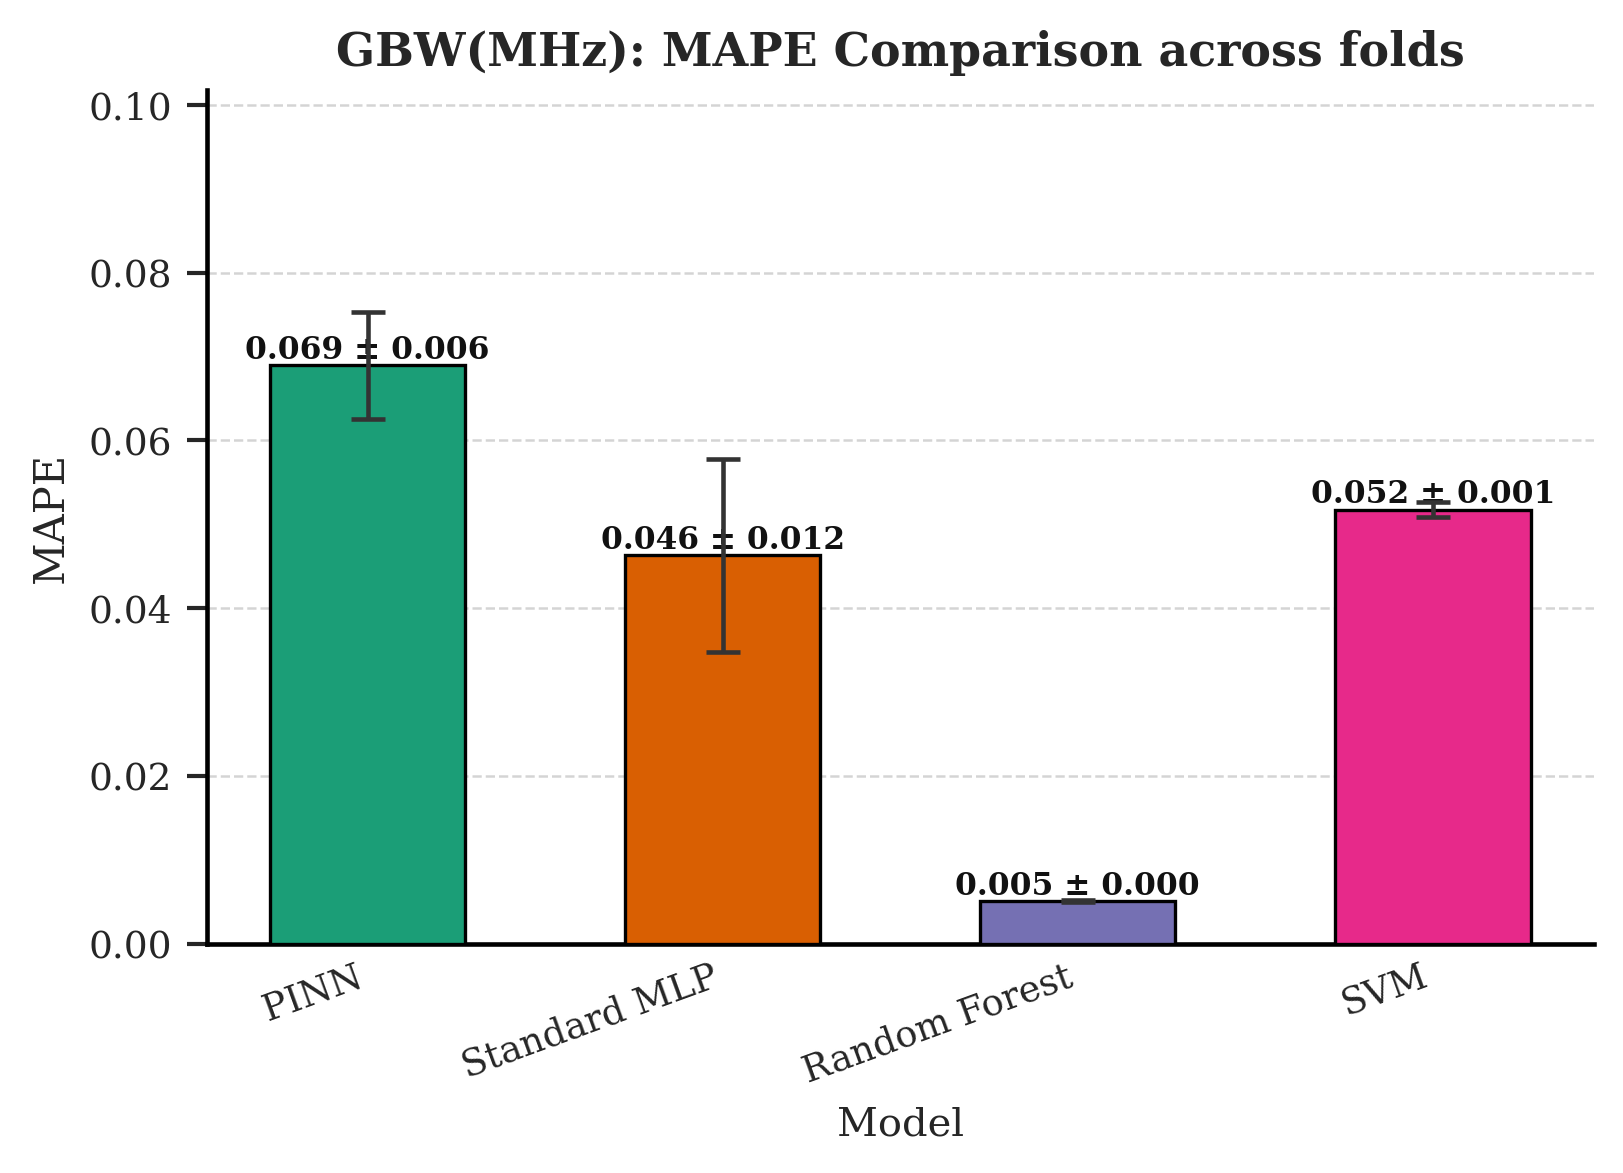

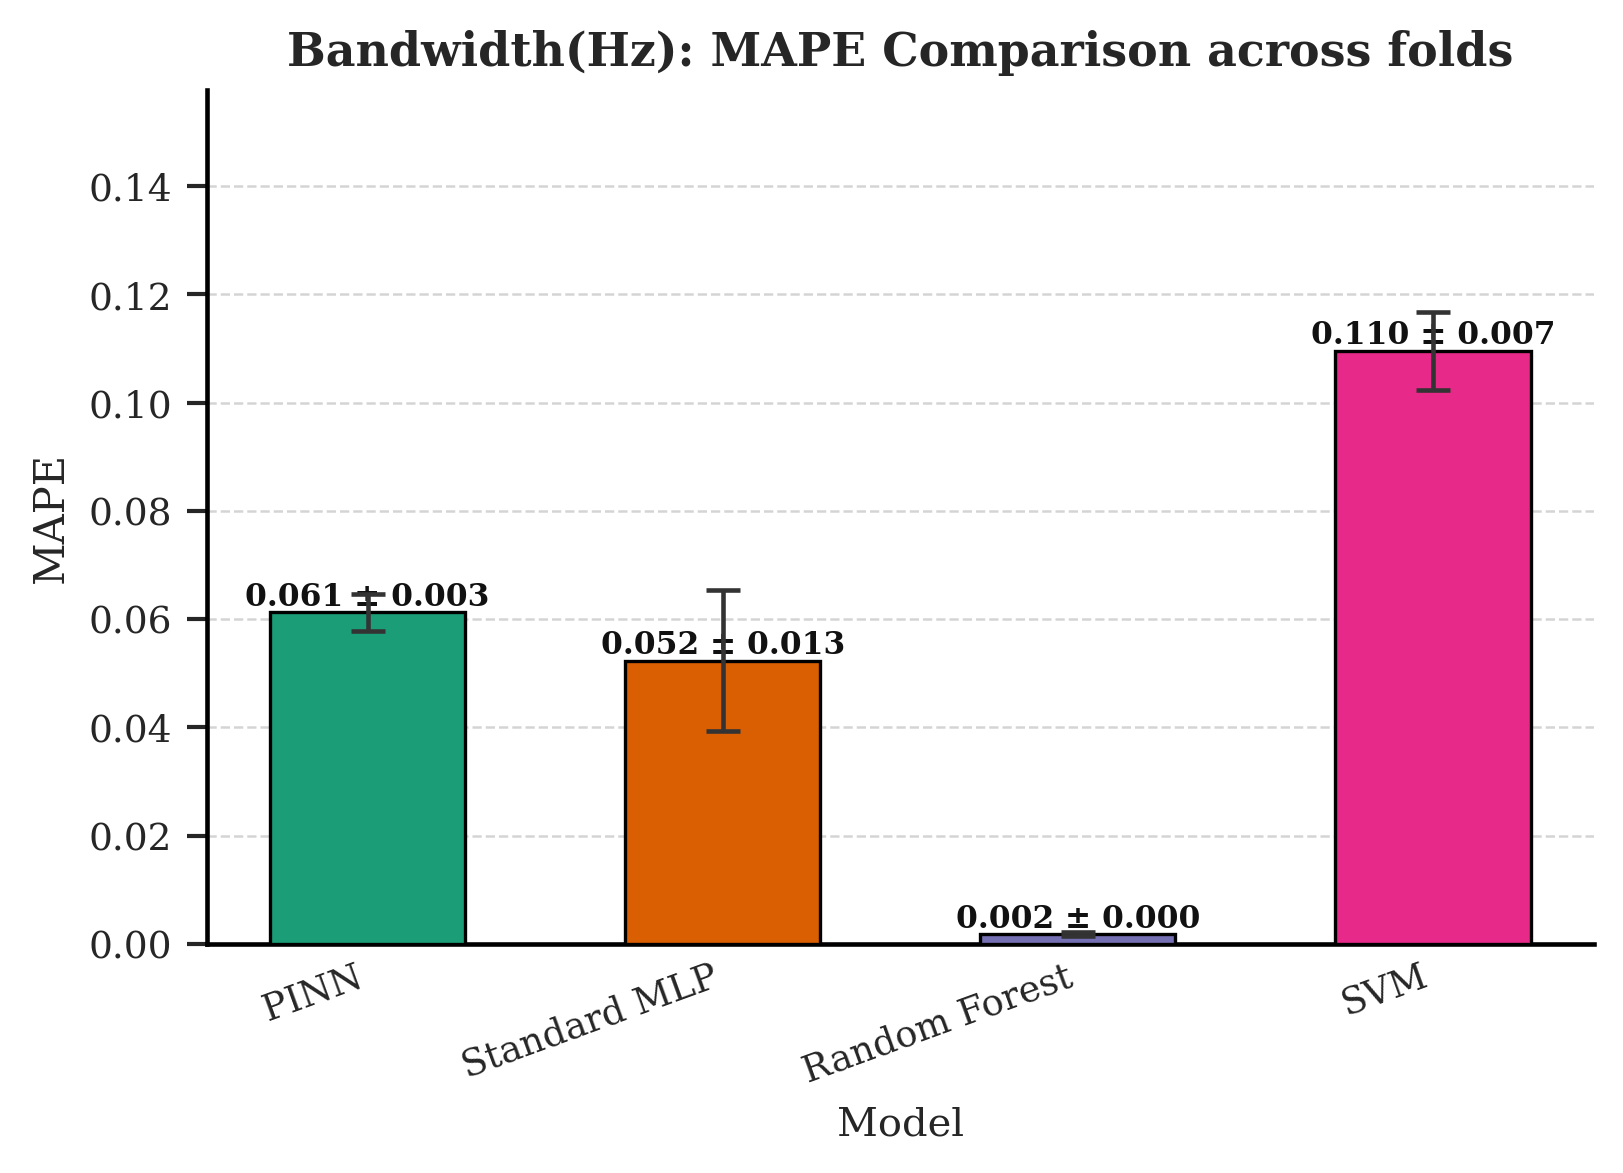

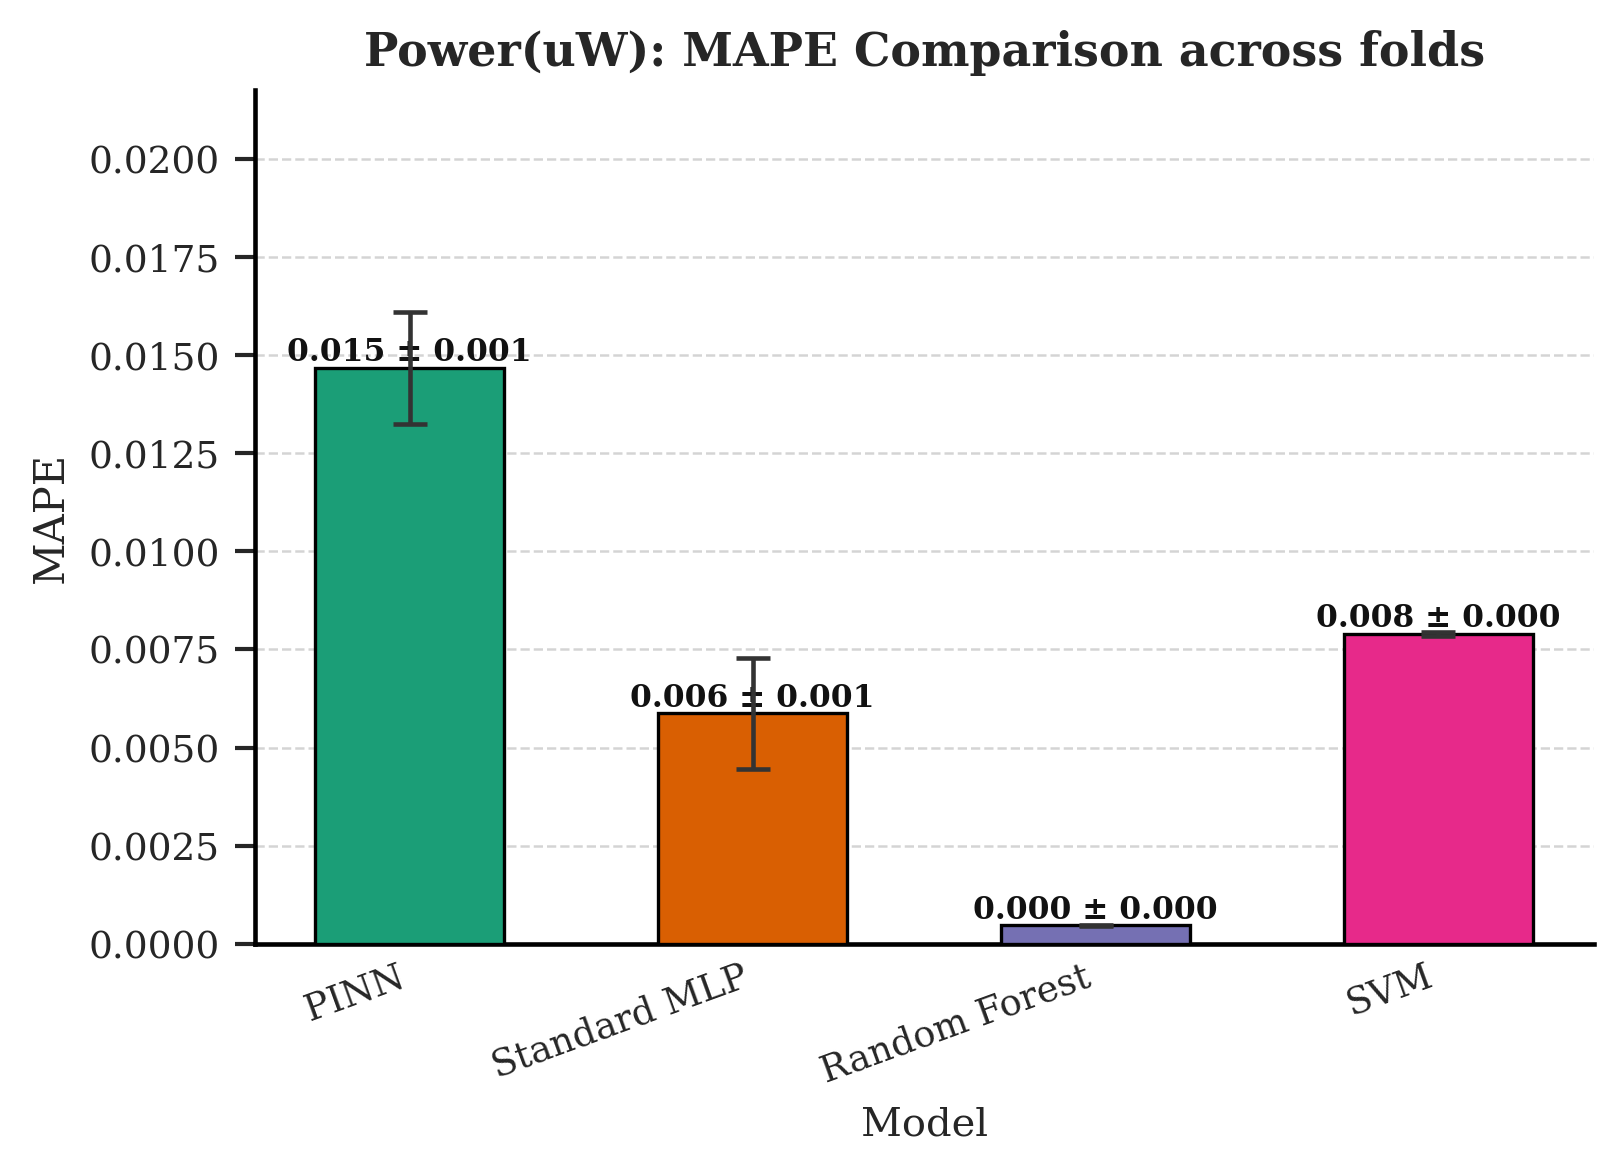

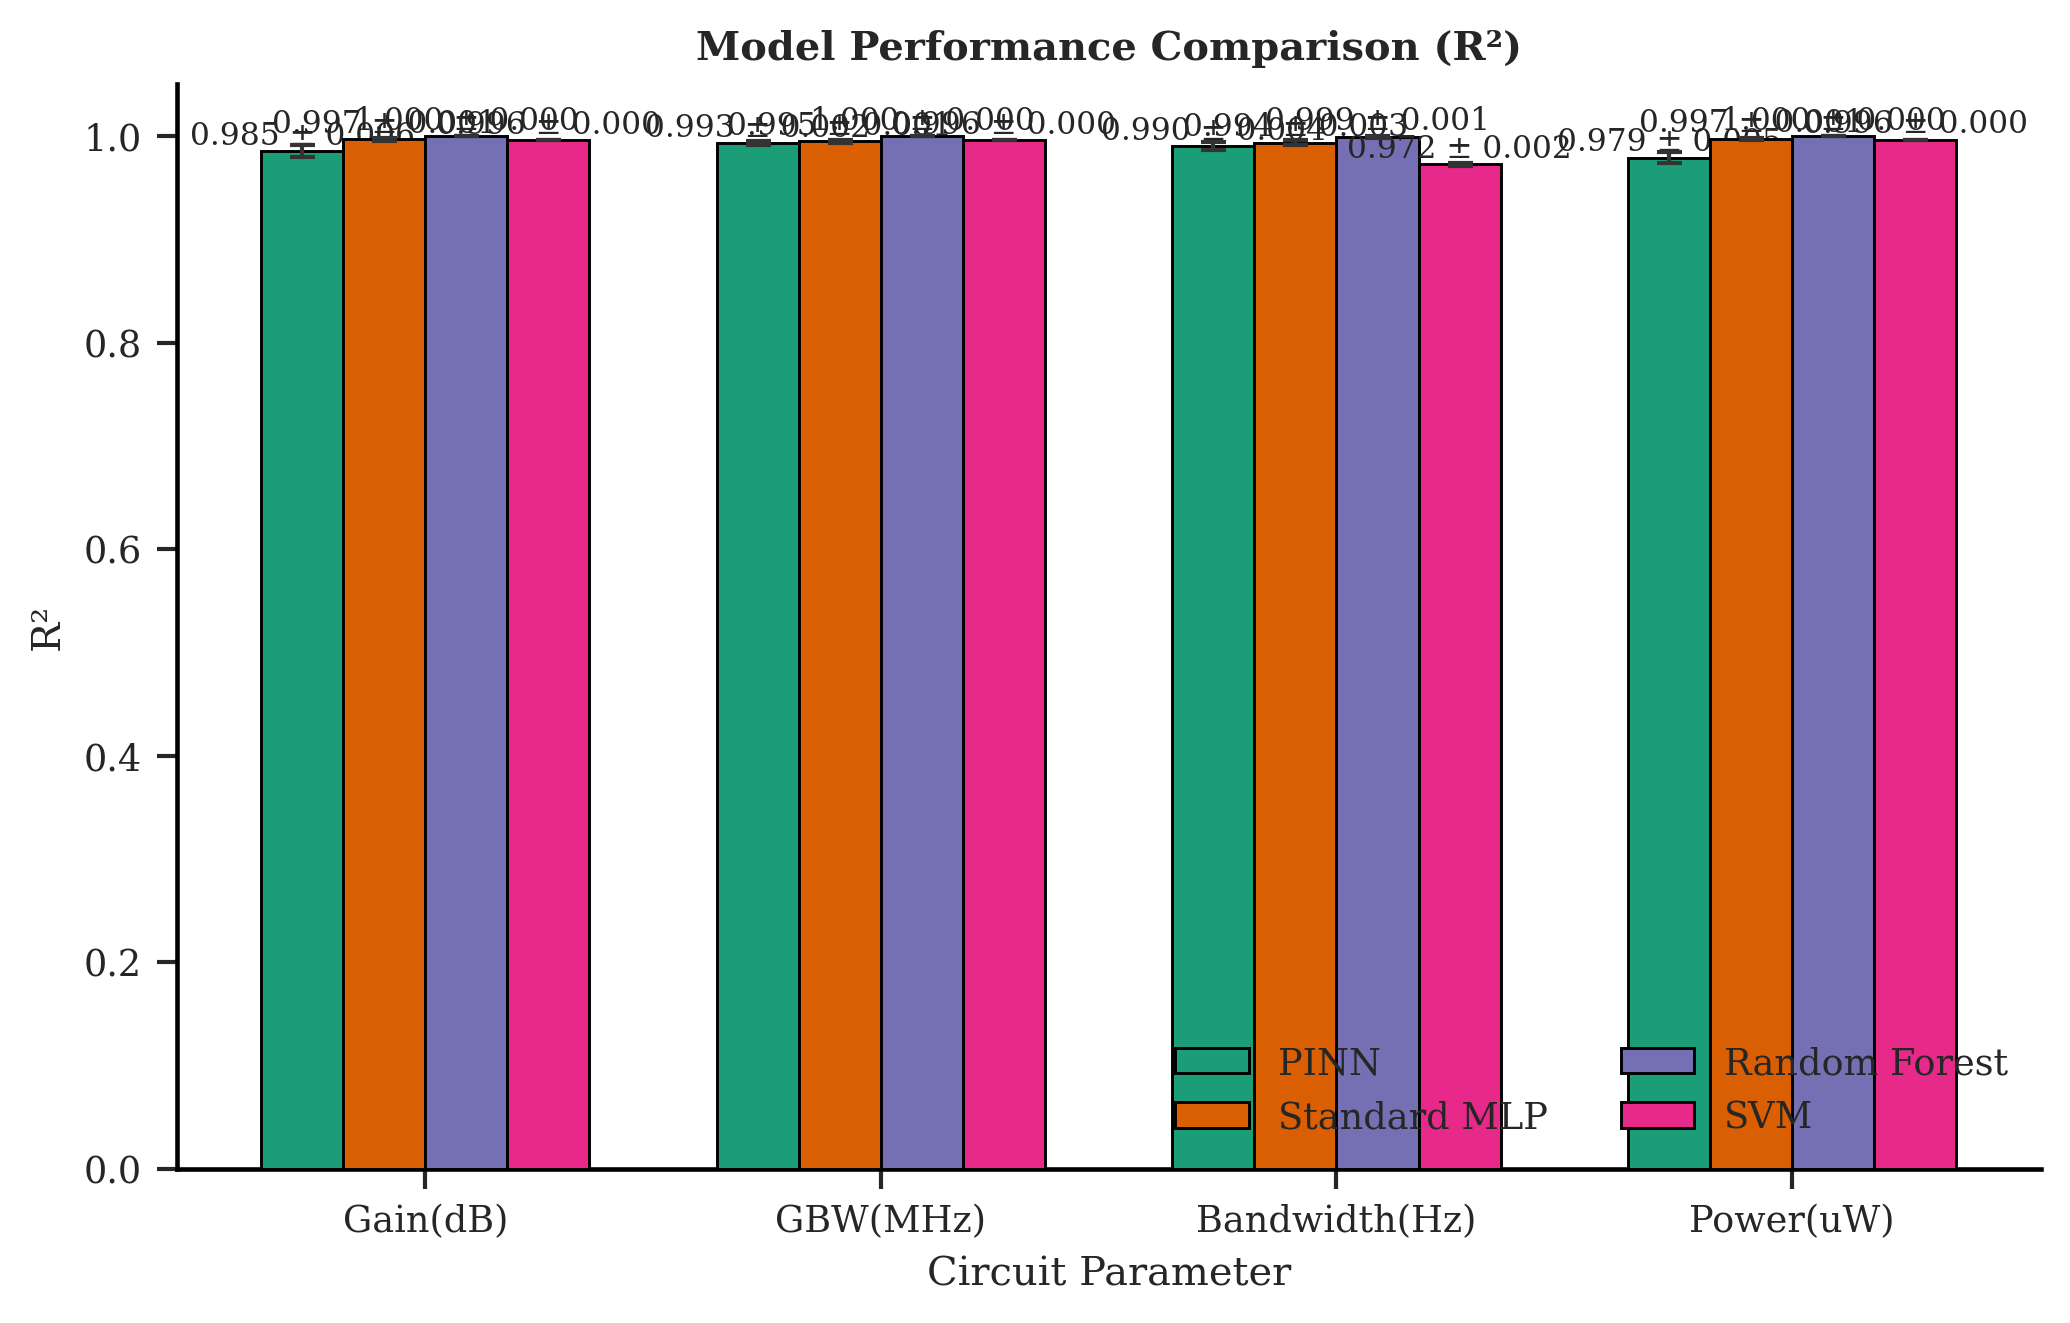

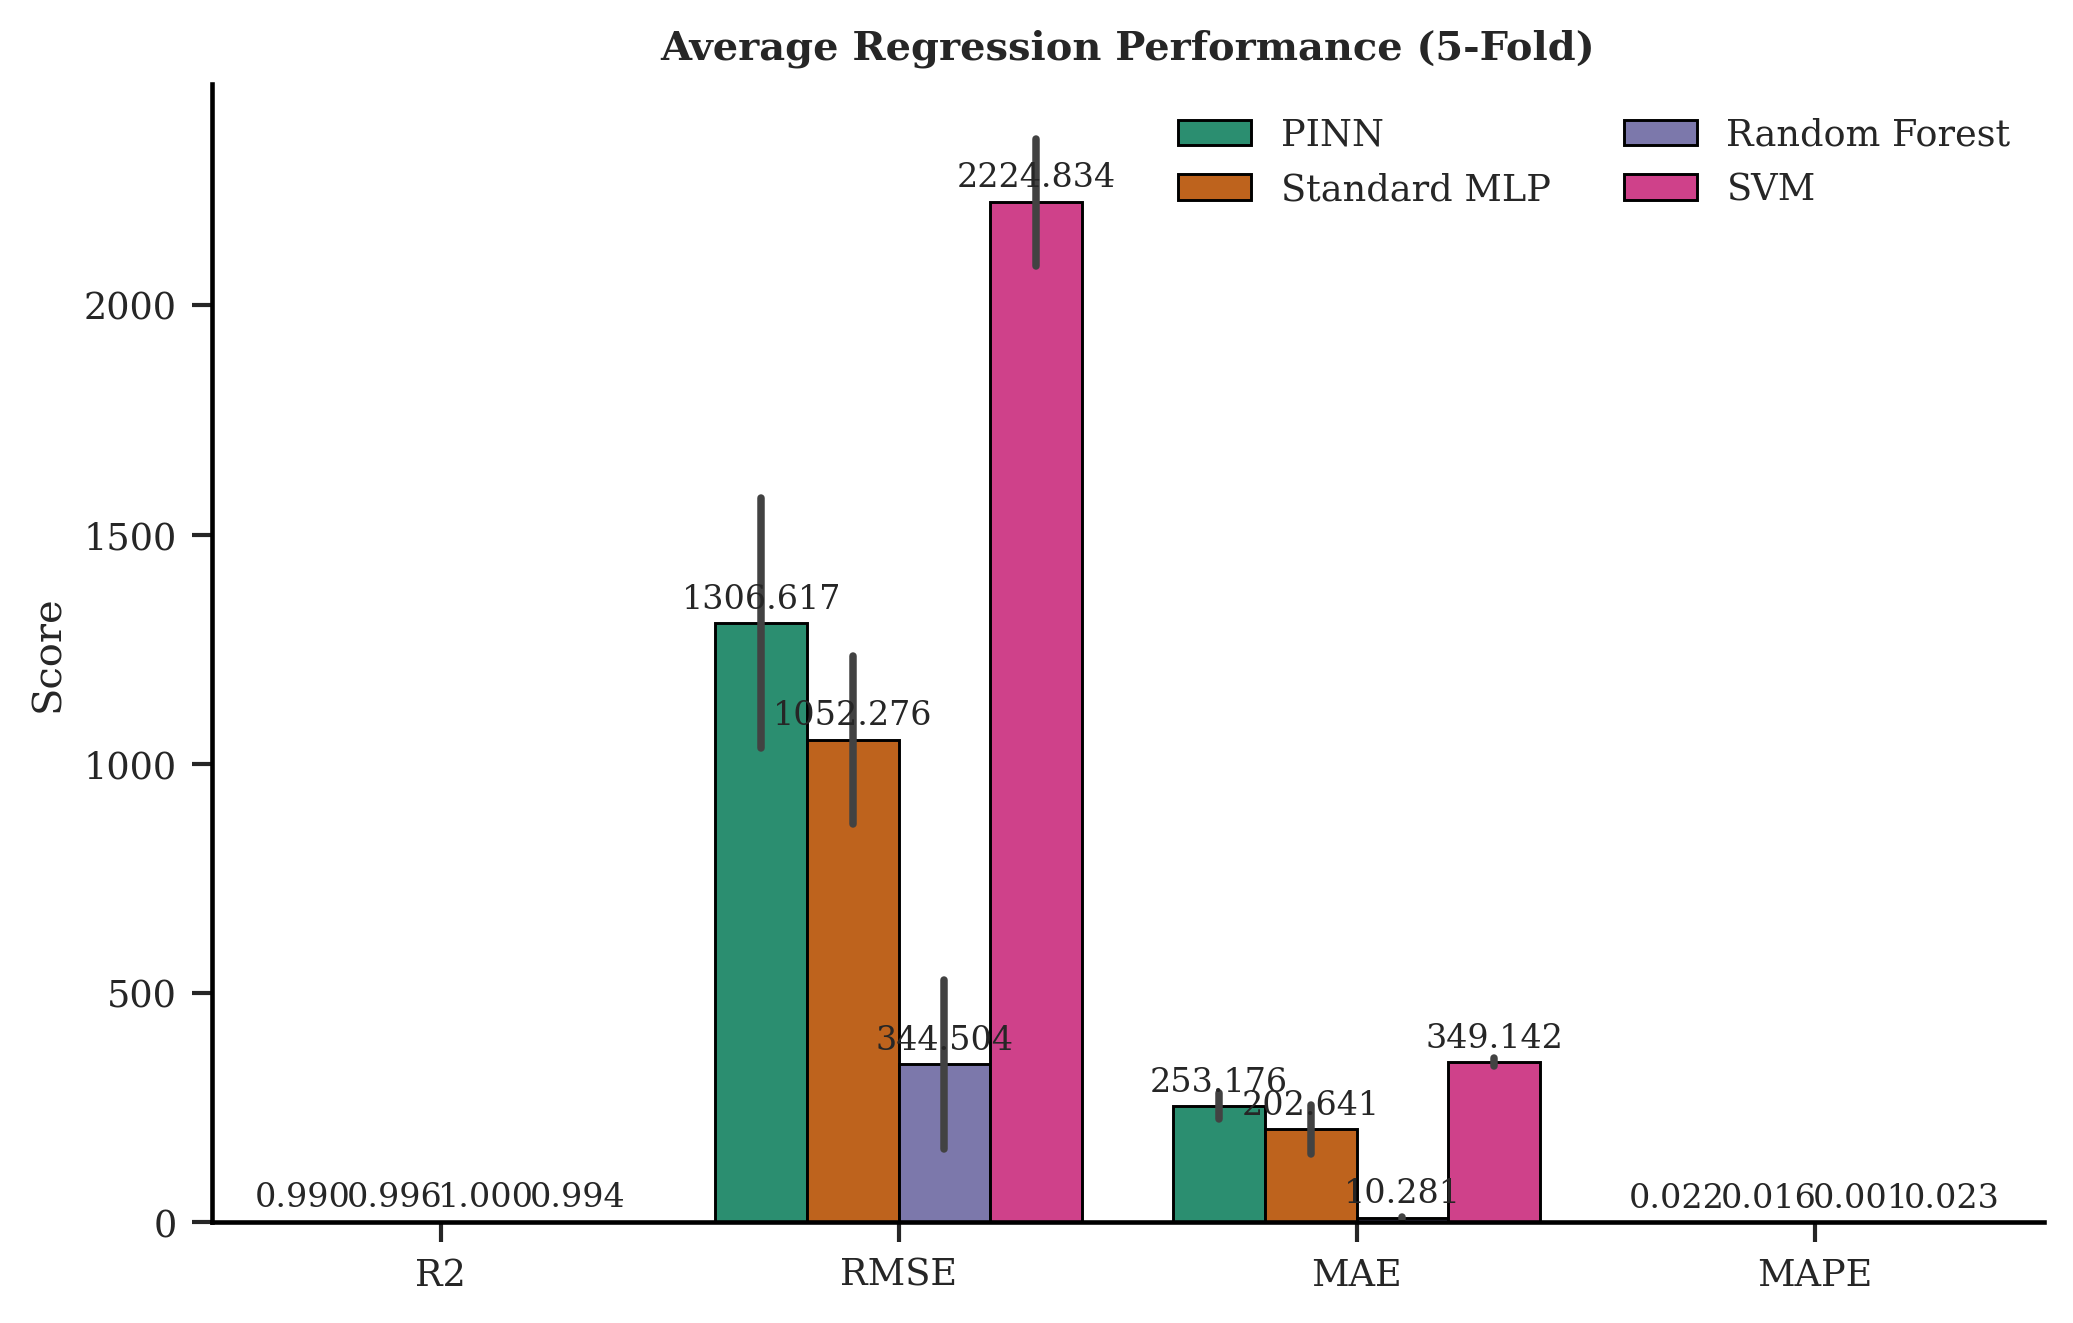

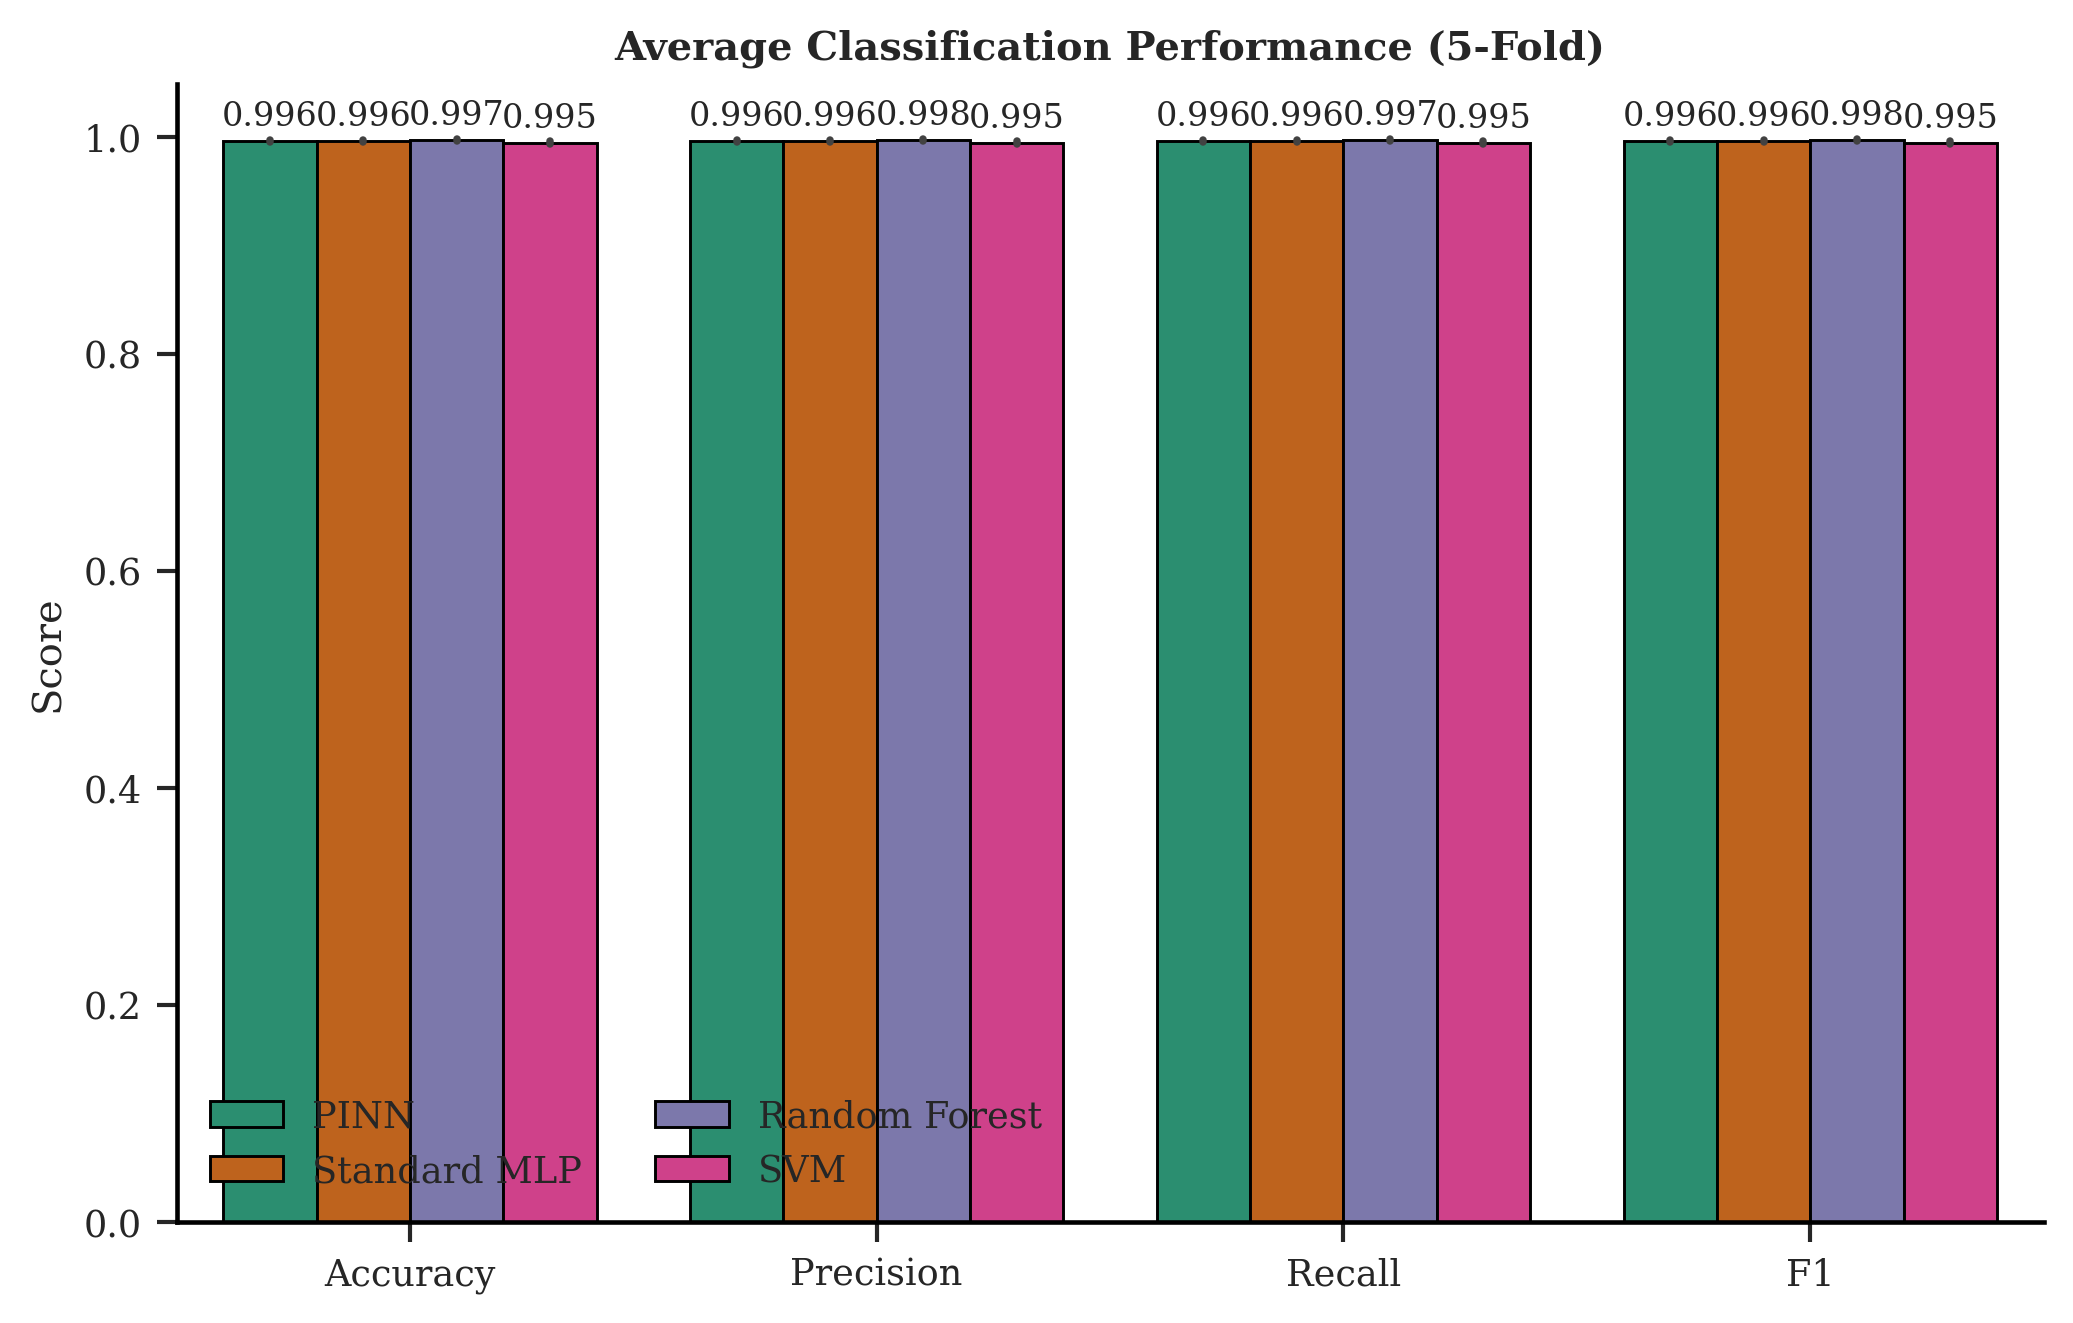

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# =========================================================
# 1. Publication Quality Plot Style (Journal Ready)
# =========================================================
sns.set_theme(context="paper", style="ticks")

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "axes.linewidth": 1.1,
    "axes.edgecolor": "black",
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Consistent colors across all plots
MODEL_COLORS = {
    'PINN': '#1b9e77',
    'Standard MLP': '#d95f02',
    'Random Forest': '#7570b3',
    'SVM': '#e7298a'
}

models = ['PINN', 'Standard MLP', 'Random Forest', 'SVM']
KEY_METRICS = ['Gain(dB)', 'GBW(MHz)', 'Bandwidth(Hz)', 'Power(uW)']

# =========================================================
# 2. Fold-wise Metric Aggregation
# =========================================================
fold_results = []
for fold_data in all_fold_predictions:
    y_true_reg = fold_data['y_true_reg']
    for name in models:
        pred_reg, _ = fold_data[name]
        for i, target_name in enumerate(REGRESSION_TARGETS):
            y_true_col = y_true_reg[:, i]
            y_pred_col = pred_reg[:, i]
            fold_results.append({
                'Model': name,
                'Metric': target_name,
                'RMSE': np.sqrt(mean_squared_error(y_true_col, y_pred_col)),
                'MAE': mean_absolute_error(y_true_col, y_pred_col),
                'MAPE': mean_absolute_percentage_error(y_true_col, y_pred_col),
                'R2': r2_score(y_true_col, y_pred_col),
            })

df_all_folds = pd.DataFrame(fold_results)
df_key = df_all_folds[df_all_folds['Metric'].isin(KEY_METRICS)].copy()

# Aggregate: mean ± std across folds
metric_summary = (
    df_key.groupby(['Model', 'Metric'])[['RMSE', 'MAE', 'MAPE', 'R2']]
    .agg(['mean', 'std'])
    .reset_index()
)
metric_summary.columns = [
    'Model', 'Metric',
    'RMSE_mean', 'RMSE_std',
    'MAE_mean', 'MAE_std',
    'MAPE_mean', 'MAPE_std',
    'R2_mean', 'R2_std',
]

def annotate_bars(ax, bars, means, stds, fmt='.3f'):
    for bar, mean_val, std_val in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height(),
            f'{mean_val:{fmt}} ± {std_val:{fmt}}',
            ha='center', va='bottom',
            fontsize=7.5, fontweight='bold', color='#111111'
        )

def style_ax(ax, ylabel, title=None):
    ax.set_ylabel(ylabel, fontsize=10)
    if title:
        ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.5, color='#aaaaaa')
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelsize=9)

# =========================================================
# 3. Metric Comparison Bar Plots
# =========================================================
score_types = ['RMSE', 'MAE', 'MAPE']
for score in score_types:
    for metric in KEY_METRICS:
        subset = metric_summary[metric_summary['Metric'] == metric].set_index('Model').loc[models]
        means = subset[f'{score}_mean'].values
        stds = subset[f'{score}_std'].values

        fig, ax = plt.subplots(figsize=(5.5, 4))
        x = np.arange(len(models))
        bars = []
        for j, (model, color) in enumerate(MODEL_COLORS.items()):
            b = ax.bar(
                x[j], means[j],
                width=0.55,
                color=color,
                edgecolor='black',
                linewidth=0.8,
                yerr=stds[j],
                capsize=4,
                error_kw=dict(elinewidth=1.1, ecolor='#333333', capthick=1.1),
                zorder=3,
                label=model,
            )
            bars.append(b[0])

        annotate_bars(ax, bars, means, stds, fmt='.3f')
        style_ax(ax, f'{score}', f'{metric}: {score} Comparison across folds')
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=20, ha='right')
        ax.set_xlabel('Model')
        ax.set_ylim(0, (means + stds).max() * 1.35)
        plt.tight_layout()
        plt.show()

# =========================================================
# 4. R² Comparison Plot
# =========================================================
fig, ax = plt.subplots(figsize=(7, 4.5))
for j, (model, color) in enumerate(MODEL_COLORS.items()):
    subset = metric_summary[metric_summary['Model'] == model].set_index('Metric').loc[KEY_METRICS]
    means = subset['R2_mean'].values
    stds = subset['R2_std'].values
    x = np.arange(len(KEY_METRICS)) + (j - 1.5) * 0.18
    ax.bar(
        x,
        means,
        width=0.18,
        color=color,
        edgecolor='black',
        linewidth=0.7,
        yerr=stds,
        capsize=3,
        error_kw=dict(elinewidth=1.0, ecolor='#333333', capthick=1.0),
        label=model,
        zorder=3,
    )
    for xpos, mean_val, std_val in zip(x, means, stds):
        ax.text(xpos, mean_val, f'{mean_val:.3f} ± {std_val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_title('Model Performance Comparison (R²)', fontweight='bold')
ax.set_xlabel('Circuit Parameter')
ax.set_ylabel('R²')
ax.set_xticks(np.arange(len(KEY_METRICS)))
ax.set_xticklabels(KEY_METRICS)
ax.legend(title='', frameon=False, ncol=2, loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

# =========================================================
# 5. Overall Performance (5-Fold Average) - Regression
# =========================================================
df_reg_melt = df_res_reg.melt(id_vars=['Model', 'Fold'], var_name='Metric', value_name='Score')

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(
    data=df_reg_melt,
    x='Metric',
    y='Score',
    hue='Model',
    palette=MODEL_COLORS,
    edgecolor='black',
    linewidth=0.7,
    errorbar='sd'
)

ax.set_title("Average Regression Performance (5-Fold)", fontweight='bold')
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend(title='', frameon=False, ncol=2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

sns.despine()
plt.tight_layout()
plt.show()

# =========================================================
# 6. Overall Performance (5-Fold Average) - Classification
# =========================================================
df_class_melt = df_res_class.melt(id_vars=['Model', 'Fold'], var_name='Metric', value_name='Score')

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(
    data=df_class_melt,
    x='Metric',
    y='Score',
    hue='Model',
    palette=MODEL_COLORS,
    edgecolor='black',
    linewidth=0.7,
    errorbar='sd'
)

ax.set_title("Average Classification Performance (5-Fold)", fontweight='bold')
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.legend(title='', frameon=False, ncol=2)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

sns.despine()
plt.tight_layout()
plt.show()